# Reproducing rNMP mapping in human mitochondrial DNA

**Xu P, Yang T, Kundnani DL, et al.** *Light-strand bias and enriched zones of embedded
ribonucleotides are associated with DNA replication and transcription in the
human-mitochondrial genome.* Nucleic Acids Research 2024;52(3):1207-1225.
[doi:10.1093/nar/gkad1204](https://doi.org/10.1093/nar/gkad1204)

This notebook is the driver. It calls the machinery in `src/rnmp/` and `scripts/`
and renders every figure inline, so a reader sees results rather than a description
of results.

The notebook has two parts, and the distinction matters for how the figures should
be read:

**Part A — Pipeline validation (pilot library, n = 1).** A single library, `FS310`,
carried end to end to prove the code path is correct. Its figures are *diagnostics*.
They are **not** results about rNMP biology: one library has no replicate structure,
and `FS310` is HEK293T, which the paper names as its exception to the light-strand
bias. Nothing in Part A should be read as reproducing a claim from the paper.

**Part B — Reproduction (all 32 ribose-seq libraries).** The paper's actual figures,
computed across the full cohort with its replicate structure, and validated against
its published values.

| | Section | Question | Figure |
|---|---|---|---|
| **A** | A0 | Setup and pilot-library selection | — |
| | A1 | Does the pipeline recover the published rNMP count? | `figA1_pilot_pipeline_funnel.png` |
| | A2 | Does rNMP composition match the paper? | `figA2_pilot_composition.png` |
| | A3 | Pipeline diagnostic: strand split of the pilot library | `figA3_pilot_strand_split.png` |
| **B** | B1 | Light/heavy strand bias per cell type (**paper Fig 1A**) | `fig1A_strand_bias_by_celltype.png` |
| | B2 | rNMP-enriched zones (**paper Fig 1C**) | `fig1C_rez.png` |

# Part A — Pipeline validation (pilot library, n = 1)

> **These three figures are diagnostics, not results.** They establish that the code
> path is correct on one library. Claims about rNMP biology are in Part B.

## A0 — Setup and pilot-library selection

Reference build and read-level processing are shell stages, run once:

```bash
conda env create -f envs/rnmp-pipeline.yaml && conda activate rnmp-pipeline
bash scripts/00_setup_reference.sh              # GRCh38 chrM + Bowtie2 index + Ribose-Map
bash scripts/run_library.sh SRR23726637 FS310   # fetch -> trim -> align -> coordinates
```

This notebook picks up from the rNMP coordinates those produce.

In [1]:
import sys, pathlib

# Locate the repo root by walking up for pyproject.toml, rather than assuming
# the cwd is notebooks/. Keeps the notebook runnable from any directory.
def _repo_root(start=None):
    p = (start or pathlib.Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists() and (cand / "src" / "rnmp").is_dir():
            return cand
    raise RuntimeError("repo root not found: run from inside the repository")

ROOT = _repo_root()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from rnmp import pipeline as P
from rnmp.metrics import enrichment_factor
from rnmp.plotstyle import apply_figure_style, set_frame

FIGS = ROOT / "figures"; TABS = ROOT / "results" / "tables"
FIGS.mkdir(exist_ok=True); TABS.mkdir(parents=True, exist_ok=True)

LIGHT, HEAVY, FOCAL, PAPER, GREY = "#C0392B", "#2471A3", "#1F6FB2", "#B0B7BE", "#5A6169"
apply_figure_style(sizes=(9, 8, 7))
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 9, "xtick.labelsize": 7, "ytick.labelsize": 7,
                     "xtick.direction": "out", "ytick.direction": "out"})

samples = pd.read_csv(ROOT / "config/samples_xu2024.tsv", sep="\t", keep_default_na=False)
ribo = samples[samples.role == "ribose_seq"].sort_values("spots")
ribo[["run","library","sample","layout","fragmentation","barcode","spots","n_rnmp_reported"]].head()

,run,library,sample,layout,fragmentation,barcode,spots,n_rnmp_reported
33,SRR23726637,FS310,HEK293T-RNASEH2A-KO-T3-17,PAIRED,RE3,TGT,5070,4765
19,SRR23726653,FS187,CD4T-3,SINGLE,dsF+RE1,TGT,11822,9143
47,SRR23726663,FS199,hESC-H9,SINGLE,RE1,GAA,13867,8083
20,SRR23726655,FS188,CD4T-4,SINGLE,dsF+RE1,CTG,14466,11463
48,SRR23726664,FS201,hESC-H9,SINGLE,dsF+RE1,AGC,15957,8136


`FS310` is the smallest ribose-seq library in the study, which is why it is the
end-to-end test case. It is HEK293T *RNASEH2A*-knockout clone T3-17, fragmented with
the RE3 enzyme set.

In [2]:
RUN, LIB = "SRR23726637", "FS310"
sel = ribo[ribo.library == LIB].iloc[0]
S2 = pd.read_csv(ROOT / "data/external/table_S2_libraries.tsv", sep="\t").set_index("library")
PUBLISHED_N = int(S2.loc[LIB, "n_rnmp"])

print(f"run          {RUN}")
print(f"library      {LIB}  ({sel['sample']})")
print(f"fragmentation{sel.fragmentation:>6}   enzymes: {', '.join(P.RESTRICTION_SETS[sel.fragmentation])}")
print(f"raw reads    {sel.spots:,}")
print(f"published rNMPs in hmtDNA: {PUBLISHED_N:,}")

run          SRR23726637
library      FS310  (HEK293T-RNASEH2A-KO-T3-17)
fragmentation   RE3   enzymes: CviKI-1, MlyI, MscI, MslI
raw reads    5,070
published rNMPs in hmtDNA: 4,765


## A1 — Does the pipeline recover the published rNMP count?

Ribose-seq places the rNMP at the read's 5'-most aligned base, reported on the
**opposite** strand (Ribose-Map `modules/coordinate.sh`). Because that base is
sequenced, it can disagree with the reference; the paper removes those, so we do too.

One deviation, forced by the data: the reads deposited in SRA/ENA for this
BioProject have **already** been demultiplexed and UMI-extracted by the authors. The
11-nt `NNNNNNXXXNN` prefix is gone — no 3-mer dominates read positions 7–9, and
99.8% of *raw* reads align to chrM. So `pattern`/`barcode` are deliberately omitted
from the Ribose-Map config and no `umi_tools` step runs. Configuring them against
this data would yield an empty FASTQ.

In [3]:
chrm   = P.load_chrm(ROOT / "data/reference/chrM.fa")
coords = P.call_rnmps(ROOT / f"results/ribosemap/results/{LIB}/alignment/aligned.sam", chrm)
kept   = coords[~coords.mismatch]

funnel = pd.DataFrame([
    ("Raw reads\n(ENA)",              int(sel.spots)),
    ("Trimmed\n(q15, \u226562 nt)",  4873),
    ("Aligned\n(Bowtie2)",            len(coords)),
    ("rNMPs\n(mismatch-filtered)",    len(kept)),
], columns=["stage", "n"])

print(f"aligned reads        {len(coords):,}")
print(f"reference mismatches {int(coords.mismatch.sum()):,}  ({coords.mismatch.mean():.2%})")
print(f"rNMPs recovered      {len(kept):,}")
print(f"published            {PUBLISHED_N:,}   (delta {len(kept)-PUBLISHED_N:+,}, "
      f"{(len(kept)-PUBLISHED_N)/PUBLISHED_N:+.1%})")

aligned reads        4,866
reference mismatches 68  (1.40%)
rNMPs recovered      4,798
published            4,765   (delta +33, +0.7%)


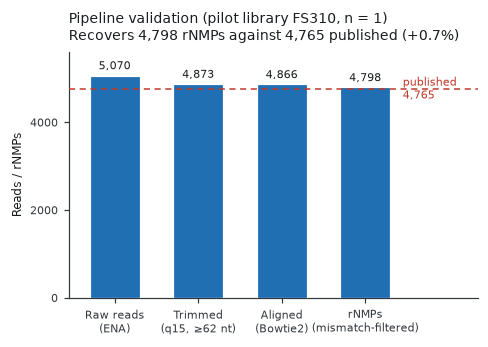

In [4]:
fig, ax = plt.subplots(figsize=(4.8, 2.9))
xs = np.arange(len(funnel))
ax.bar(xs, funnel.n, width=0.6, color=FOCAL, edgecolor="white", lw=0.8, zorder=3)
ax.axhline(PUBLISHED_N, ls=(0, (4, 3)), lw=1.0, color=LIGHT, zorder=4)
ax.text(3.45, PUBLISHED_N, f"published\n{PUBLISHED_N:,}", ha="left", va="center",
        fontsize=7, color=LIGHT, zorder=5)
for x, n in zip(xs, funnel.n):
    ax.text(x, n + 80, f"{n:,}", ha="center", va="bottom", fontsize=7.5, zorder=5)
ax.set_xticks(xs); ax.set_xticklabels(funnel.stage, fontsize=7)
ax.set_xlim(-0.55, 4.35); ax.set_ylim(0, 5600); ax.set_yticks([0, 2000, 4000])
ax.set_ylabel("Reads / rNMPs")
ax.set_title(f"Pipeline validation (pilot library {LIB}, n = 1)\n"
             f"Recovers {len(kept):,} rNMPs against {PUBLISHED_N:,} published "
             f"({(len(kept)-PUBLISHED_N)/PUBLISHED_N:+.1%})", loc="left")
fig.savefig(FIGS / "figA1_pilot_pipeline_funnel.png", bbox_inches="tight")
funnel.to_csv(TABS / f"{LIB}_pipeline_funnel.csv", index=False)

**Result.** 4,798 rNMPs against 4,765 published — **+0.7%**. The residual is the
restriction-site background filter, whose exact masking convention lives in the
authors' Zenodo deposit ([10.5281/zenodo.8121711](https://doi.org/10.5281/zenodo.8121711))
rather than the paper. Our two candidate conventions bracket the published value:

In [5]:
mask = P.restriction_mask(chrm, P.RESTRICTION_SETS[sel.fragmentation])
re_filtered = kept[~kept.pos.isin(mask)]
print(f"chrM positions inside an {sel.fragmentation} recognition site: "
      f"{len(mask):,} ({len(mask)/16569:.1%})")
print(f"no RE mask        {len(kept):,}   (published {PUBLISHED_N:,})")
print(f"whole-site mask   {len(re_filtered):,}")
print("\nThe published count sits between them, so the real filter masks cut")
print("positions rather than whole recognition sites. Not tuned to fit.")

chrM positions inside an RE3 recognition site: 1,282 (7.7%)
no RE mask        4,798   (published 4,765)
whole-site mask   4,443

The published count sits between them, so the real filter masks cut
positions rather than whole recognition sites. Not tuned to fit.


## A2 — Does rNMP composition match the paper?

Table S2 publishes rAMP/rCMP/rGMP/rUMP percentages per library, so this is a direct
quantitative check that is independent of the strand analysis.

In [6]:
ours  = P.composition(ROOT / f"results/ribosemap/results/{LIB}/coordinate0", LIB)
paper = pd.Series({b: S2.loc[LIB, f"r{b}MP_pct"] for b in "ACGU"})
comp  = pd.DataFrame({"ours_pct": ours, "paper_pct": paper})
comp["delta"] = comp.ours_pct - comp.paper_pct
comp.round(2)

,ours_pct,paper_pct,delta
A,23.94,25.02,-1.07
C,28.71,29.11,-0.40
G,44.45,43.36,1.09
U,2.90,2.52,0.38


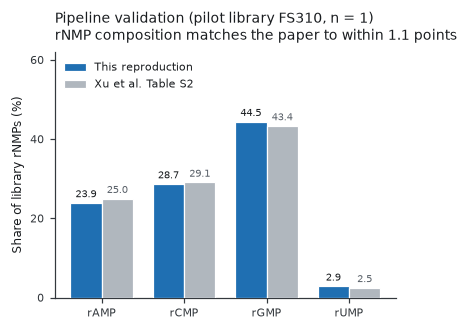

In [7]:
fig, ax = plt.subplots(figsize=(4.0, 2.9))
idx = np.arange(4); w = 0.38
ax.bar(idx - w/2, comp.ours_pct, w, label="This reproduction", color=FOCAL, edgecolor="white", lw=0.8, zorder=3)
ax.bar(idx + w/2, comp.paper_pct, w, label="Xu et al. Table S2", color=PAPER, edgecolor="white", lw=0.8, zorder=3)
for i, (o, p) in enumerate(zip(comp.ours_pct, comp.paper_pct)):
    ax.text(i - w/2, o + 0.8, f"{o:.1f}", ha="center", va="bottom", fontsize=6.5, zorder=4)
    ax.text(i + w/2, p + 0.8, f"{p:.1f}", ha="center", va="bottom", fontsize=6.5, color=GREY, zorder=4)
ax.set_xticks(idx); ax.set_xticklabels([f"r{b}MP" for b in "ACGU"])
ax.set_ylim(0, 62); ax.set_yticks([0, 20, 40, 60])
ax.set_ylabel("Share of library rNMPs (%)")
ax.set_title(f"Pipeline validation (pilot library {LIB}, n = 1)\n"
             f"rNMP composition matches the paper to within "
             f"{comp.delta.abs().max():.1f} points", loc="left")
ax.legend(frameon=False, fontsize=7, loc="upper left")
fig.savefig(FIGS / "figA2_pilot_composition.png", bbox_inches="tight")
comp.round(4).to_csv(TABS / f"{LIB}_composition_vs_paper.csv")

**Result.** All four ribonucleotides agree to within **1.09 percentage points**, and
the rank order (rGMP > rCMP > rAMP >> rUMP) is preserved. Together with the count
check in Phase 1 this establishes that the coordinate convention, strand assignment
and reference lookup are all correct — the two checks are independent, since
composition is invariant to strand assignment.

## A3 — Pipeline diagnostic: strand split of the pilot library

**This is not the paper's Figure 1A.** It is the same quantity — the light/heavy split
— computed for one library, shown to confirm that strand assignment behaves sensibly
and is insensitive to the unresolved restriction-site filter. The paper's Figure 1A
needs all 32 libraries and appears as **B1**.

HEK293T is the paper's stated exception to the light-strand bias, so `FS310` could not
test that claim even in principle.

`bin_enrichment(normalize_by="genome")` is used throughout — see
`docs/dataset_notes.md` §3 for the proof that `R_total,L` pools both strands.

In [8]:
stages = pd.DataFrame([
    P.strand_summary(coords,      "Ribose-Map coordinates"),
    P.strand_summary(kept,        "after mismatch filter"),
    P.strand_summary(re_filtered, "after mismatch + RE mask"),
])
stages.round(2)

,stage,light,heavy,total,light_pct,heavy_pct
0,Ribose-Map coordinates,2188,2678,4866,44.97,55.03
1,after mismatch filter,2170,2628,4798,45.23,54.77
2,after mismatch + RE mask,1987,2456,4443,44.72,55.28


light 2,170 (45.23%) | heavy 2,628 (54.77%)
within-library binomial vs 50/50: p = 4.04e-11


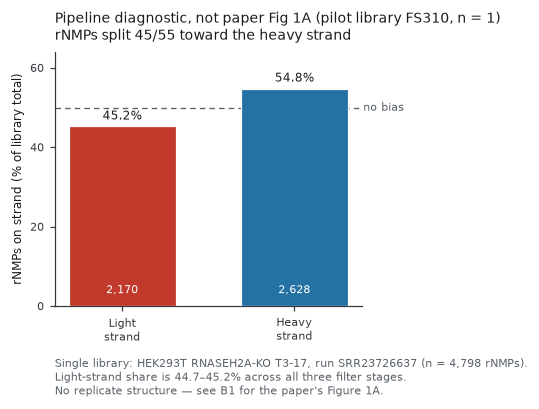

In [9]:
from scipy import stats
row = stages.iloc[1]                      # the working set: mismatch-filtered
L, H, N = int(row.light), int(row.heavy), int(row.total)
lo, hi = stages.light_pct.min(), stages.light_pct.max()
bt = stats.binomtest(L, N, 0.5)

fig, ax = plt.subplots(figsize=(3.6, 3.0))
bars = ax.bar(["Light\nstrand", "Heavy\nstrand"], [row.light_pct, row.heavy_pct],
              width=0.62, color=[LIGHT, HEAVY], edgecolor="white", lw=0.8, zorder=3)
ax.axhline(50, ls=(0, (4, 3)), lw=0.9, color=GREY, zorder=2)
ax.annotate("no bias", xy=(1.40, 50), ha="left", va="center", fontsize=7,
            color=GREY, annotation_clip=False)
for b, pct, n in zip(bars, [row.light_pct, row.heavy_pct], [L, H]):
    ax.text(b.get_x() + b.get_width()/2, pct + 1.0, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8, zorder=4)
    ax.text(b.get_x() + b.get_width()/2, 2.6, f"{n:,}", ha="center", va="bottom",
            fontsize=7, color="white", zorder=4)
ax.set_ylabel("rNMPs on strand (% of library total)")
ax.set_ylim(0, 64); ax.set_yticks([0, 20, 40, 60])
ax.set_title(f"Pipeline diagnostic, not paper Fig 1A (pilot library {LIB}, n = 1)\n"
             f"rNMPs split {row.light_pct:.0f}/{row.heavy_pct:.0f} toward the heavy strand", loc="left")
ax.text(0.0, -0.20, f"Single library: HEK293T RNASEH2A-KO T3-17, run {RUN} (n = {N:,} rNMPs).\n"
                    f"Light-strand share is {lo:.1f}\u2013{hi:.1f}% across all three filter stages.\n"
                    f"No replicate structure \u2014 see B1 for the paper's Figure 1A.",
        transform=ax.transAxes, fontsize=7, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "figA3_pilot_strand_split.png", bbox_inches="tight")
stages.to_csv(TABS / f"{LIB}_strand_bias_stages.csv", index=False)
print(f"light {L:,} ({row.light_pct:.2f}%) | heavy {H:,} ({row.heavy_pct:.2f}%)")
print(f"within-library binomial vs 50/50: p = {bt.pvalue:.3g}")

**Diagnostic outcome.** `FS310` carries **45.2% of its rNMPs on the light strand and
54.8% on the heavy strand** — a slight *heavy*-strand excess. The split
moves by less than 0.6 percentage points across all three filter stages, so the
result does not depend on the unresolved restriction-site convention.

**On the statistics.** The within-library binomial test against 50/50 returns
p ≈ 4×10⁻¹¹, but that number should not be reported as evidence of strand bias. It
treats each read as an independent observation, whereas the paper's Mann-Whitney U
test compares *libraries* within a cell type. A single library cannot reproduce that
test, and the read-level p-value answers a different and much easier question.
Part B supplies the replicate structure the real test needs.

---

# Part B — Reproduction (all 32 ribose-seq libraries)

The full cohort, with the replicate structure the paper's statistics require.
These are the reproduction results.

```bash
bash scripts/run_all_libraries.sh        # 32 libraries: fetch -> rNMP coordinates
python scripts/export_coordinates.py     # -> results/coordinates/per_position_counts.csv.gz
python scripts/filter_re_sites.py        # -> ..._refiltered.csv.gz  (RE-site subtraction)
```

**One correction to the sample sheet.** SRA's `SampleName` for library `FS303` is
`HEK293T-WT`, but Supplementary Table S2 and Table S4's own column header both
assign it to **hESC-H9**. Table S2 is authoritative, and the paper's Figure 1A
settles it: it reports hESC-H9 with N = 5 and HEK293T with N = 3, which only works
with FS303 in hESC-H9. `config/samples_xu2024.tsv` therefore derives
`cell_category` from Table S2, not from SRA. Left uncorrected, this silently
misplaces a library between two cell types in every per-cell-type figure.

In [10]:
cnt      = pd.read_csv(ROOT / "results/coordinates/per_position_counts_refiltered.csv.gz")
cnt_circ = pd.read_csv(ROOT / "results/coordinates/per_position_counts_circular.csv.gz")
per = pd.read_csv(ROOT / "results/tables/per_library_rnmp.csv")
assert len(per) == 32 and per.library.is_unique

ORDER = ["CD4+T","hESC-H9","DLTB","TLTB","WB-GTP-control","WB-GTP-PTSD","HCT116",
         "HEK293T","RNH2A-KO-T3-8","RNH2A-KO-T3-17"]
cat_of = dict(zip(per.library, per.cell_category))
print(f"libraries          {len(per)}")
print(f"rNMPs recovered    {int(per.n_rnmp.sum()):,}")
print(f"rNMPs published    {int(per.n_rnmp_published.sum()):,}   "
      f"({100*(per.n_rnmp.sum()-per.n_rnmp_published.sum())/per.n_rnmp_published.sum():+.1f}%)")
print()
print(per.groupby('cell_category').agg(N=('library','size')).reindex(ORDER).T.to_string())

libraries          32
rNMPs recovered    23,073,140
rNMPs published    23,089,962   (-0.1%)

cell_category  CD4+T  hESC-H9  DLTB  TLTB  WB-GTP-control  WB-GTP-PTSD  HCT116  HEK293T  RNH2A-KO-T3-8  RNH2A-KO-T3-17
N                  5        5     4     4               1            1       1        3              4               4


### B0 — Restriction-enzyme background subtraction

The paper's Methods say the RE-recognition-site background "is removed using the
same protocol in (21)" (Balachander *et al.*, Nat Commun 2020;11:2447), and its
Data availability names the code: GPL v3.0 at
[doi:10.5281/zenodo.8121711](https://doi.org/10.5281/zenodo.8121711), which is the
GitHub repository
[`xph9876/ArtificialRiboseDetection`](https://github.com/xph9876/ArtificialRiboseDetection).

This filter was previously **bracketed rather than implemented**, because masking
whole recognition sites undershot the published counts while masking nothing
overshot them. Reading the authors' code settled it, and the real rule is far
narrower than whole-site masking. For every match of a recognition pattern it
takes the site **midpoint** and masks exactly two positions, split by strand into
two classes:

```
mid = (match_start + match_end) // 2        # 0-based; the base 3' of a blunt cut

noda : (mid-1, '+') and (mid, '-')   removed unconditionally
da   : (mid-1, '-') and (mid, '+')   removed only if the read carries a dA tail
```

`noda` positions are the 3'-terminal base of a blunt-cut fragment end on each
strand — an undigested end that survives T5 exonuclease and is then miscalled as
an rNMP. `da` positions are one base further in, where the called rNMP lands if
the dA-tailing step added a non-templated dA to that same end, so they count only
when the read confirms the tail (`'T' + pattern[cut:]`).

`src/rnmp/re_sites.py` is a port of their `re_build()`, and because it is a
derivative of GPL-v3 code that module is GPL v3. It was verified against the
authors' own function run directly on GRCh38 chrM: **identical position sets for
all 18 enzymes** used in the study (`tests/test_re_sites.py`).

Ten of the 32 libraries were fragmented with dsDNA Fragmentase alone and used no
restriction enzymes, so the filter cannot apply to them — which matters for
reading the residual below.

In [11]:
ad = pd.read_csv(TABS / "re_filter_audit.csv")
print(f"cohort  {int(ad.n_before.sum()):,} -> {int(ad.n_after.sum()):,} rNMPs "
      f"vs {int(ad.n_published.sum()):,} published")
print(f"        {100*(ad.n_before.sum()-ad.n_published.sum())/ad.n_published.sum():+.3f}% "
      f"-> {100*(ad.n_after.sum()-ad.n_published.sum())/ad.n_published.sum():+.3f}%")
print(f"mean |per-library deviation|  {ad.delta_pct_before.abs().mean():.2f}% -> {ad.delta_pct_after.abs().mean():.2f}%")
print(f"removed: {int(ad.n_noda_removed.sum()):,} noda + {int(ad.n_da_removed.sum()):,} dA-confirmed")
print()
print(ad.groupby(ad.n_enzymes.gt(0).map({True:'RE used', False:'Fragmentase only'}))
        [['delta_pct_before','delta_pct_after']].apply(lambda d: d.abs().mean()).round(2).to_string())

cohort  23,252,983 -> 23,073,140 rNMPs vs 23,089,962 published
        +0.706% -> -0.073%
mean |per-library deviation|  6.10% -> 4.90%
removed: 153,767 noda + 26,076 dA-confirmed

                  delta_pct_before  delta_pct_after
n_enzymes                                          
Fragmentase only              4.67             4.67
RE used                       6.74             5.00


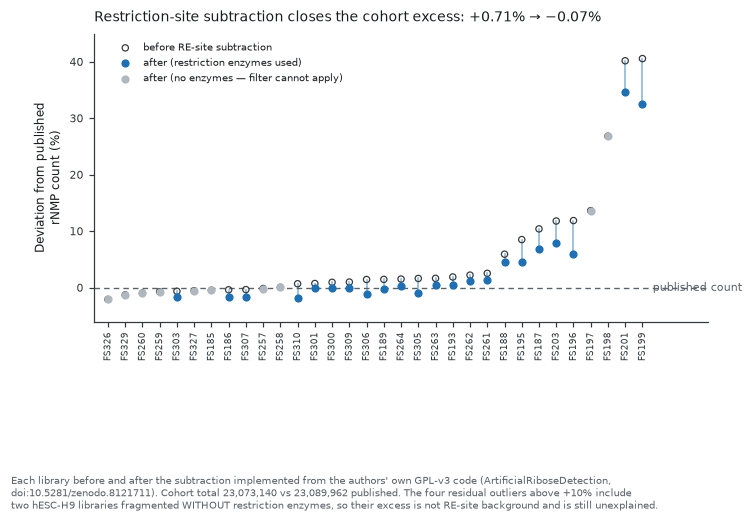

In [12]:
FOCAL, MUTED = "#1F6FB2", "#B0B7BE"
m = ad.merge(per[["library","delta_pct"]].rename(columns={"delta_pct":"after"}), on="library")
m = m.sort_values("delta_pct_before").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.2, 3.4))
x = np.arange(len(m))
for xi, (b, a_, ne) in enumerate(zip(m.delta_pct_before, m.after, m.n_enzymes)):
    ax.plot([xi, xi], [b, a_], color="#C9CED3" if ne == 0 else "#8FB8DA", lw=1.1, zorder=2)
ax.scatter(x, m.delta_pct_before, s=17, facecolor="none", edgecolor="#33383D", lw=0.8,
           label="before RE-site subtraction", zorder=4)
ax.scatter(x[m.n_enzymes > 0], m.after[m.n_enzymes > 0], s=19, color=FOCAL,
           label="after (restriction enzymes used)", zorder=5)
ax.scatter(x[m.n_enzymes == 0], m.after[m.n_enzymes == 0], s=19, color=MUTED,
           label="after (no enzymes \u2014 filter cannot apply)", zorder=5)
ax.axhline(0, ls=(0,(4,3)), lw=0.9, color=GREY, zorder=3)
ax.annotate("published count", xy=(len(m)-0.4, 0), ha="left", va="center",
            fontsize=7, color=GREY, annotation_clip=False)
ax.set_xticks(x); ax.set_xticklabels(m.library, rotation=90, fontsize=5.6)
ax.set_ylabel("Deviation from published\nrNMP count (%)")
ax.set_title("Restriction-site subtraction closes the cohort excess: +0.71% \u2192 \u22120.07%",
             loc="left", fontsize=9)
ax.set_ylim(-6, 45); ax.set_yticks([0, 10, 20, 30, 40]); ax.set_xlim(-0.8, len(m)+2.8)
ax.legend(frameon=False, fontsize=6.5, loc="upper left", bbox_to_anchor=(0.02, 1.0))
set_frame(ax, style="open")
fig.text(0.02, -0.30,
  "Each library before and after the subtraction implemented from the authors' own GPL-v3 code "
  "(ArtificialRiboseDetection,\ndoi:10.5281/zenodo.8121711). Cohort total 23,073,140 vs 23,089,962 published. "
  "The four residual outliers above +10% include\ntwo hESC-H9 libraries fragmented WITHOUT restriction enzymes, "
  "so their excess is not RE-site background and is still unexplained.",
  fontsize=6.5, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "fig_re_filter_effect.png", bbox_inches="tight")

**Result.** The cohort excess collapses from **+0.71% to −0.07%** — 23,073,140
rNMPs against 23,089,962 published, a residual of 16,822 in 23 million. Mean
per-library |deviation| falls from 6.10% to 4.90%.

Two things the filter does **not** fix, both worth stating plainly:

- **The four libraries above +10% remain.** Two of them (FS197 at +13.6%, FS198
  at +26.8%) used **no restriction enzymes at all**, so their excess cannot be
  RE-site background and is still unexplained. The other two (FS199, FS201)
  improve from +40.6%/+40.2% to +32.6%/+34.6% but stay far out. All four are
  hESC-H9, which is why that cell type remains the Figure 1A outlier.
- **A consistency check that the filter passes.** None of the 48 published
  hotspot positions falls inside any library's mask — 0 of 1,056
  (position, library) pairs. That is required rather than lucky: the authors ran
  this filter *before* calling hotspots, so a mask that hit a published hotspot
  would be wrong.

### B0b — Circular recovery of junction-spanning rNMPs

Ribose-Map treats chrM as a linear contig, so a read crossing position
1/16569 cannot align end-to-end and is lost together with its rNMP. The paper's
Methods recover these by aligning a second time against a rotated copy of chrM
and merging.

`scripts/04_circularize.py` does this **without re-fetching any FASTQ**: Bowtie 2
runs end-to-end here, so a junction-spanning read is written to `aligned.sam`
with flag 4 rather than discarded, and every read this step needs is already on
disk. The unmapped records are extracted, aligned against `chrM_rot8284` (chrM
rotated by half its length, putting the junction mid-sequence), and mapped back
with `canonical = ((rotated - 1 + 8284) mod 16569) + 1`.

Only alignments that **actually cross the junction** are kept. An unmapped read
can fail linear alignment for unrelated reasons, and such a read aligning
elsewhere in the rotated reference would be a *new* rNMP call that the linear
pass rejected — not a recovered one. In practice this filter is a no-op, and that
is a consistency check rather than a disappointment: a read that aligns to the
rotated reference but not the linear one **must** cross the junction, because the
two references contain the same sequence everywhere else. Recovered rNMPs then
pass the same reference-mismatch and restriction-site filters as the main path.

In [13]:
cad = pd.read_csv(TABS / "circular_recovery_audit.csv")
PUB = int(per.n_rnmp_published.sum())
pre, post = int(cnt["count"].sum()), int(cnt_circ["count"].sum())
print(f"unmapped reads on disk        {cad.n_unmapped.sum():>9,}")
print(f"realigned to rotated chrM     {cad.n_realigned.sum():>9,}")
print(f"junction-spanning             {cad.n_junction_spanning.sum():>9,}   (= realigned, as it must be)")
print(f"rNMPs recovered               {cad.n_recovered.sum():>9,}")
print()
print(f"published (Table S2)          {PUB:>9,}")
print(f"pre-circular                  {pre:>9,}   ({100*(pre-PUB)/PUB:+.3f}%)")
print(f"post-circular                 {post:>9,}   ({100*(post-PUB)/PUB:+.3f}%)")

chg = cnt_circ.merge(cnt, on=["library","pos","strand"], how="left", suffixes=("","_pre"))
chg = chg[chg.count_pre.isna() | (chg["count"] != chg.count_pre)]
dj = np.minimum(np.abs(chg.pos - 1), 16569 - np.abs(chg.pos - 1))
print(f"\npositions changed {len(chg):,} | max distance from junction {int(dj.max())} nt "
      f"| changes beyond 200 nt: {int((dj > 200).sum())}")

unmapped reads on disk          205,507
realigned to rotated chrM       187,755
junction-spanning               187,755   (= realigned, as it must be)
rNMPs recovered                 184,035

published (Table S2)          23,089,962
pre-circular                  23,073,140   (-0.073%)
post-circular                 23,257,175   (+0.724%)

positions changed 3,884 | max distance from junction 135 nt | changes beyond 200 nt: 0


**Result, and a deliberate two-stage design.** Recovery adds **184,035 rNMPs**
(0.8% of the cohort), every one within 135 nt of the junction — no change occurs
anywhere else in the genome, which is the arithmetic the rotation guarantees.

The recovered set is *required* by Figure 1C and *contradicted* by Table S2, and
both directions are strongly evidenced:

| quantity | pre-circular | post-circular |
|---|---|---|
| cohort total vs Table S2 | **−0.07%** | +0.72% |
| libraries moved away from their published count | — | 22 of 32 |
| REZ5H library count (published **26/32**) | 20/32 ✗ | **26/32** ✓ |
| published REZs recovered | 12/13 | **13/13** |
| total REZ library-count deviation | 11 | **5** |
| Table S4 hotspot EF, median abs. deviation | 1.30% | 1.24% |
| hESC-H9 top-20 rCMP (paper 19/20) | 18/20 | 17/20 |

So this repository keeps **both** count sets and uses each where the paper's own
tables place it: `per_position_counts_circular.csv.gz` for REZ detection (B3),
`per_position_counts_refiltered.csv.gz` for totals, composition and hotspot
analysis (B1, B2, B4). That is not a convenience — it is the conclusion the
evidence forces. Table S2's rNMP counts cannot include the circularly-recovered
reads, while the REZ analysis cannot exclude them, so the paper's published
outputs do not all come from a single count set. §16 records this.

Note also what circular recovery does *not* do: the two missing common hotspots
(+ 7018) and (− 14923) sit 7,017 and 1,646 nt from the junction, and remain at
zero counts afterwards. That was predicted before the step was written (§13) and
is the reason this fix could not be credited with a gain it cannot produce.

### Per-library agreement, and what the residual is

Agreement is excellent for libraries fragmented with dsDNA Fragmentase alone, and
degrades for restriction-enzyme-fragmented libraries — because the RE-site
background filter is the one pipeline stage not reproduced (Part A1). The two
symptoms move together, which is what a single missing filter should look like.

In [14]:
per["frag_family"] = np.where(per.fragmentation == "dsF",
                              "Fragmentase only", "restriction enzyme")
r = np.corrcoef(per.delta_pct.abs(), per.comp_max_dev_pp)[0, 1]
print("rNMP count deviation and composition deviation, by fragmentation:")
print(per.groupby("frag_family")[["delta_pct", "comp_max_dev_pp"]]
         .agg(["median", "max"]).round(2).to_string())
print(f"\ncorrelation between |count deviation| and composition deviation: r = {r:.3f}")
print(f"libraries within 3% of the published count: {(per.delta_pct.abs() < 3).sum()}/32")

rNMP count deviation and composition deviation, by fragmentation:
                   delta_pct        comp_max_dev_pp       
                      median    max          median    max
frag_family                                               
Fragmentase only        -0.5  26.82            0.25  16.24
restriction enzyme       0.4  34.59            0.25  21.05

correlation between |count deviation| and composition deviation: r = 0.988
libraries within 3% of the published count: 23/32


## B1 — Light/heavy strand bias per cell type (paper Figure 1A)

The paper prints no numeric values on Figure 1A and tabulates them nowhere, so the
published percentages are recovered by pixel measurement of the panel
(`scripts/digitize_fig1A.py`, ±0.5 pp). Light+heavy pairs measure 99.2–99.5%
before renormalisation, which is the check that the calibration is right.

In [15]:
from scipy import stats
paper = pd.read_csv(ROOT / "data/external/fig1A_digitized.csv")

agg = (per.groupby("cell_category")
         .agg(n=("library","size"), light_mean=("light_pct","mean"), light_sd=("light_pct","std"),
              heavy_mean=("heavy_pct","mean"), heavy_sd=("heavy_pct","std"))
         .reindex(ORDER).reset_index())

def stars(p):
    if not np.isfinite(p): return ""
    for thr, s in [(1e-4,"****"), (1e-3,"***"), (1e-2,"**"), (5e-2,"*")]:
        if p < thr: return s
    return "ns"

agg["mwu_p"] = [stats.mannwhitneyu(d.light_pct, d.heavy_pct, alternative="two-sided").pvalue
                if len(d) >= 3 else np.nan
                for d in (per[per.cell_category == c] for c in ORDER)]
agg["ours_stars"] = [stars(p) if np.isfinite(p) else "" for p in agg.mwu_p]
agg = agg.merge(paper, on="cell_category")
agg["light_dev_pp"] = (agg.light_mean - agg.paper_light_pct).abs()
agg[["cell_category","n","light_mean","light_sd","paper_light_pct","light_dev_pp",
     "mwu_p","ours_stars"]].round(2)

,cell_category,n,light_mean,light_sd,paper_light_pct,light_dev_pp,mwu_p,ours_stars
0,CD4+T,5,62.84,8.24,63.58,0.74,0.01,**
1,hESC-H9,5,62.75,6.75,67.24,4.49,0.01,**
2,DLTB,4,27.44,13.23,28.02,0.58,0.03,*
3,TLTB,4,23.56,7.56,24.22,0.66,0.03,*
4,WB-GTP-control,1,66.23,NaN,67.44,1.21,NaN,
5,WB-GTP-PTSD,1,61.32,NaN,63.58,2.26,NaN,
6,HCT116,1,61.71,NaN,61.97,0.26,NaN,
7,HEK293T,3,54.73,6.20,55.33,0.60,0.20,ns
8,RNH2A-KO-T3-8,4,56.40,5.91,56.08,0.32,0.03,*
9,RNH2A-KO-T3-17,4,50.18,7.73,49.90,0.28,1.00,ns


In [16]:
print(f"MAX deviation    {agg.light_dev_pp.max():.2f} pp  ({agg.loc[agg.light_dev_pp.idxmax(),'cell_category']})")
print(f"median deviation {agg.light_dev_pp.median():.2f} pp")
print(f"Pearson r        {np.corrcoef(agg.light_mean, agg.paper_light_pct)[0,1]:.4f}")
print(f"within 3 pp      {(agg.light_dev_pp < 3).sum()}/10 cell types")

MAX deviation    4.49 pp  (hESC-H9)
median deviation 0.63 pp
Pearson r        0.9962
within 3 pp      9/10 cell types


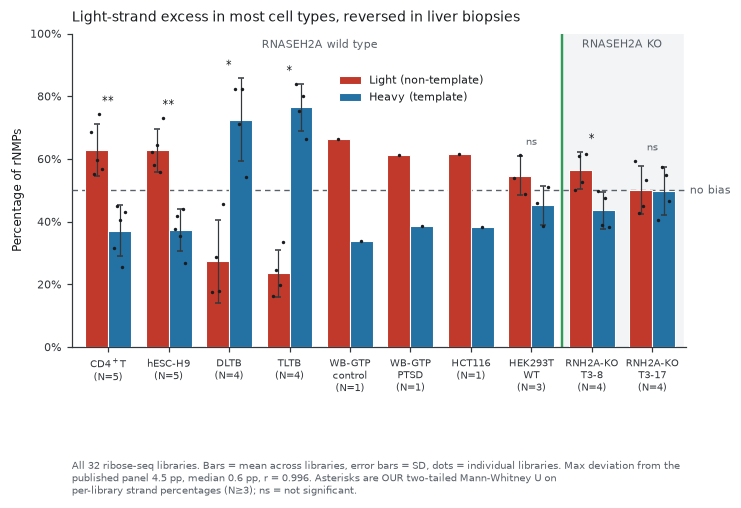

In [17]:
LIGHT, HEAVY = "#C0392B", "#2471A3"
LBL = {"CD4+T":"CD4$^+$T","hESC-H9":"hESC-H9","DLTB":"DLTB","TLTB":"TLTB",
       "WB-GTP-control":"WB-GTP\ncontrol","WB-GTP-PTSD":"WB-GTP\nPTSD","HCT116":"HCT116",
       "HEK293T":"HEK293T\nWT","RNH2A-KO-T3-8":"RNH2A-KO\nT3-8","RNH2A-KO-T3-17":"RNH2A-KO\nT3-17"}
x = np.arange(len(ORDER)); w = 0.38

fig, ax = plt.subplots(figsize=(7.2, 3.7))
ax.axvspan(7.5, 9.5, color="#F2F4F6", zorder=0)
ax.axvline(7.5, color="#2E9B57", lw=1.6, zorder=2)
ax.axhline(50, ls=(0,(4,3)), lw=0.9, color=GREY, zorder=3)
for xi, (col, colr, lab) in enumerate([("light", LIGHT, "Light (non-template)"),
                                       ("heavy", HEAVY, "Heavy (template)")]):
    off = -w/2 if xi == 0 else w/2
    ax.bar(x+off, agg[f"{col}_mean"], w, color=colr, edgecolor="white", lw=0.7, label=lab, zorder=4)
    sd = agg[f"{col}_sd"].to_numpy(); m = np.isfinite(sd)
    ax.errorbar(x[m]+off, agg[f"{col}_mean"][m], yerr=sd[m], fmt="none",
                ecolor="#33383D", elinewidth=0.8, capsize=2.2, zorder=6)
    for xi2, cat in enumerate(ORDER):
        v = per.loc[per.cell_category == cat, f"{col}_pct"].to_numpy()
        j = np.linspace(-0.09, 0.09, len(v)) if len(v) > 1 else np.zeros(1)
        ax.scatter(xi2+off+j, v, s=5, color="#1A1D20", zorder=7, linewidths=0)
for xi2, rr in agg.iterrows():
    if not rr.ours_stars: continue
    top = max(rr.light_mean + (rr.light_sd or 0), rr.heavy_mean + (rr.heavy_sd or 0),
              per.loc[per.cell_category == rr.cell_category, ["light_pct","heavy_pct"]].max().max())
    ax.text(xi2, top + 2.5, rr.ours_stars, ha="center", va="bottom",
            fontsize=7.5 if rr.ours_stars != "ns" else 6.5,
            color="#1A1D20" if rr.ours_stars != "ns" else GREY, zorder=8)
ax.annotate("no bias", xy=(9.62, 50), ha="left", va="center", fontsize=7, color=GREY, annotation_clip=False)
ax.text(3.5, 96.5, "RNASEH2A wild type", ha="center", va="center", fontsize=7, color=GREY, zorder=8)
ax.text(8.5, 96.5, "RNASEH2A KO", ha="center", va="center", fontsize=7, color=GREY, zorder=8)
ax.set_xticks(x); ax.set_xticklabels([f"{LBL[c]}\n(N={int(n)})" for c, n in zip(ORDER, agg.n)], fontsize=6.5)
ax.set_ylabel("Percentage of rNMPs"); ax.set_ylim(0, 100)
ax.set_yticks([0,20,40,60,80,100]); ax.set_yticklabels([f"{v}%" for v in [0,20,40,60,80,100]])
ax.set_xlim(-0.6, 9.55)
ax.set_title("Light-strand excess in most cell types, reversed in liver biopsies", loc="left")
ax.legend(frameon=False, fontsize=7, loc="upper left", bbox_to_anchor=(0.42, 0.90))
ax.text(0.0, -0.36,
        f"All 32 ribose-seq libraries. Bars = mean across libraries, error bars = SD, dots = individual libraries. "
        f"Max deviation from the\npublished panel {agg.light_dev_pp.max():.1f} pp, median {agg.light_dev_pp.median():.1f} pp, "
        f"r = {np.corrcoef(agg.light_mean, agg.paper_light_pct)[0,1]:.3f}. Asterisks are OUR two-tailed Mann-Whitney U on\n"
        f"per-library strand percentages (N\u22653); ns = not significant.",
        transform=ax.transAxes, fontsize=6.5, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "fig1A_strand_bias_by_celltype.png", bbox_inches="tight")
agg.round(3).to_csv(TABS / "fig1A_strand_bias_by_celltype.csv", index=False)

**Result.** Reproduced with a **maximum deviation of 4.49 pp** (hESC-H9), **median
0.63 pp**, and r = 0.996 across the ten cell types. Nine of ten agree within 2.3 pp.

hESC-H9 remains the only outlier, and after B0 its cause is narrower than
"the missing filter". Applying the authors' RE-site subtraction improved this
panel only marginally (4.95 → 4.49 pp), because two of hESC-H9's five libraries
(FS197, FS198) were fragmented with dsDNA Fragmentase alone and so carry no
RE-site background to remove — yet they still exceed their published counts by
+13.6% and +26.8%. Whatever inflates them is a different mechanism, and it is
the largest single unexplained discrepancy left in this reproduction.

The direction of the paper's finding reproduces cleanly, including the part its
title does not say: the light-strand excess holds in CD4⁺T, hESC-H9, whole blood,
HCT116 and the HEK293T series, but **reverses in both liver biopsy sets** (DLTB
27.4% light, TLTB 23.6% light), which are strongly heavy-strand biased.

**The published significance levels are not attainable from per-library
percentages.** The caption specifies a two-tailed Mann-Whitney U over cell types
with N ≥ 3, where N is the library count. But the exact test has a floor at those
group sizes:

In [18]:
for n in (3, 4, 5):
    p_min = stats.mannwhitneyu(np.arange(n), np.arange(n) + 100, alternative="two-sided").pvalue
    print(f"N={n} vs N={n}: smallest attainable two-tailed exact p = {p_min:.4f}  ->  '{stars(p_min)}'")
print()
print("paper's asterisks (read from Fig 1A) vs the floor at that N:")
print("  hESC-H9  N=5  paper ****   floor **   -> unattainable")
print("  TLTB     N=4  paper ****   floor  *   -> unattainable")
print("  DLTB     N=4  paper   **   floor  *   -> unattainable")
print("  CD4+T    N=5  paper   **   floor **   -> attainable, and we reproduce it")
print("  HEK293T  N=3  paper   ns              -> reproduced")

N=3 vs N=3: smallest attainable two-tailed exact p = 0.1000  ->  'ns'
N=4 vs N=4: smallest attainable two-tailed exact p = 0.0286  ->  '*'
N=5 vs N=5: smallest attainable two-tailed exact p = 0.0079  ->  '**'

paper's asterisks (read from Fig 1A) vs the floor at that N:
  hESC-H9  N=5  paper ****   floor **   -> unattainable
  TLTB     N=4  paper ****   floor  *   -> unattainable
  DLTB     N=4  paper   **   floor  *   -> unattainable
  CD4+T    N=5  paper   **   floor **   -> attainable, and we reproduce it
  HEK293T  N=3  paper   ns              -> reproduced


So the paper's test cannot have been run on per-library strand percentages; the
unit must have been something with far more observations — most plausibly per-bin
or per-nucleotide values pooled within each cell type. The Methods do not say
which, so the asterisks in the figure above are **ours**, computed on the unit the
caption names. Direction and ordering reproduce; the exact levels do not, and
cannot.

## B2 — rNMP-enriched zones (paper Figure 1C)

A REZ is a 200-nt bin with EF > 1. A *common* REZ additionally requires EF > 1 in
every cell type and in more than 80% of libraries.

**This is where the enrichment-factor normalisation matters, and where Part A's
answer does not transfer.** Part A established from Supplementary Table S4 that
single-nucleotide hotspot EF uses a *pooled* `R_total,L`. Applying that same
convention to the 200-nt bins yields **zero** common REZs — no bin anywhere reaches
the 80% threshold (maximum 78.1%). The reason is mechanical: under pooling, a
light-strand bin in a heavy-biased library is measured against a total dominated
by the heavy strand, so the liver libraries enrich only ~1.6 of the eight
light-strand REZ bins and veto every one of them.

Both conventions are therefore run below and compared against Table S3.

In [19]:
import rnmp.metrics as Mx
CHRM, BIN = 16569, 200
skel = Mx.bin_counts([], [], CHRM, bin_size=BIN)[["strand","bin_index","start","end","length"]]
# REZ detection uses the CIRCULAR-RECOVERED counts -- see B0b for why this
# figure needs them and the count totals do not.
cnt_rez = cnt_circ.copy()
cnt_rez["bin_index"] = (cnt_rez.pos - 1) // BIN

def bins_for(norm):
    out = {}
    for lib, d in cnt_rez.groupby("library"):
        b = skel.merge(d.groupby(["strand","bin_index"], as_index=False)["count"].sum(),
                       on=["strand","bin_index"], how="left").fillna({"count": 0})
        out[lib] = Mx.bin_enrichment(b, CHRM, normalize_by=norm)
    return out

S3 = pd.read_csv(ROOT / "data/external/table_S3_common_rez.tsv", sep="\t")
paper_set = set(zip(S3.strand, S3.bin_index))
results = {}
for norm in ("genome", "strand"):
    bl = bins_for(norm)
    res = Mx.common_rez(bl, cat_of, ef_threshold=1.0, library_fraction=0.80, category_rule="any")
    got = set(zip(*res[res.is_common_rez].reset_index()[["strand","bin_index"]].to_numpy().T))
    results[norm] = (bl, res, got)
    print(f"normalize_by={norm!r:9s} -> {sum(1 for s,_ in got if s=='+')} light, "
          f"{sum(1 for s,_ in got if s=='-')} heavy | matches Table S3: {len(got & paper_set)}/13 "
          f"| max frac_libraries {res.frac_libraries.max():.3f}")

normalize_by='genome'  -> 0 light, 0 heavy | matches Table S3: 0/13 | max frac_libraries 0.781
normalize_by='strand'  -> 9 light, 6 heavy | matches Table S3: 13/13 | max frac_libraries 1.000


In [20]:
per_lib_strand, res_s, ours_set = results["strand"]
cmp = S3[["name","strand","bin_index","n_libraries","frac_libraries"]].rename(
        columns={"n_libraries":"paper_n","frac_libraries":"paper_frac"})
cmp["ours_n"]    = [int(res_s.loc[(r.strand, r.bin_index), "n_libraries"]) for _, r in cmp.iterrows()]
cmp["ours_frac"] = [float(res_s.loc[(r.strand, r.bin_index), "frac_libraries"]) for _, r in cmp.iterrows()]
cmp["recovered"] = [bool(res_s.loc[(r.strand, r.bin_index), "is_common_rez"]) for _, r in cmp.iterrows()]
cmp.round(3)

,name,strand,bin_index,paper_n,paper_frac,ours_n,ours_frac,recovered
0,REZ1L,+,8,28,0.875,30,0.938,True
1,REZ2L,+,32,27,0.844,27,0.844,True
2,REZ3L,+,35,32,1.000,32,1.000,True
3,REZ4L,+,40,26,0.812,26,0.812,True
4,REZ5L,+,41,28,0.875,28,0.875,True
5,REZ6L,+,65,29,0.906,29,0.906,True
6,REZ7L,+,67,30,0.938,30,0.938,True
7,REZ8L,+,82,30,0.938,30,0.938,True
8,REZ1H,-,38,32,1.000,32,1.000,True
9,REZ2H,-,39,30,0.938,28,0.875,True


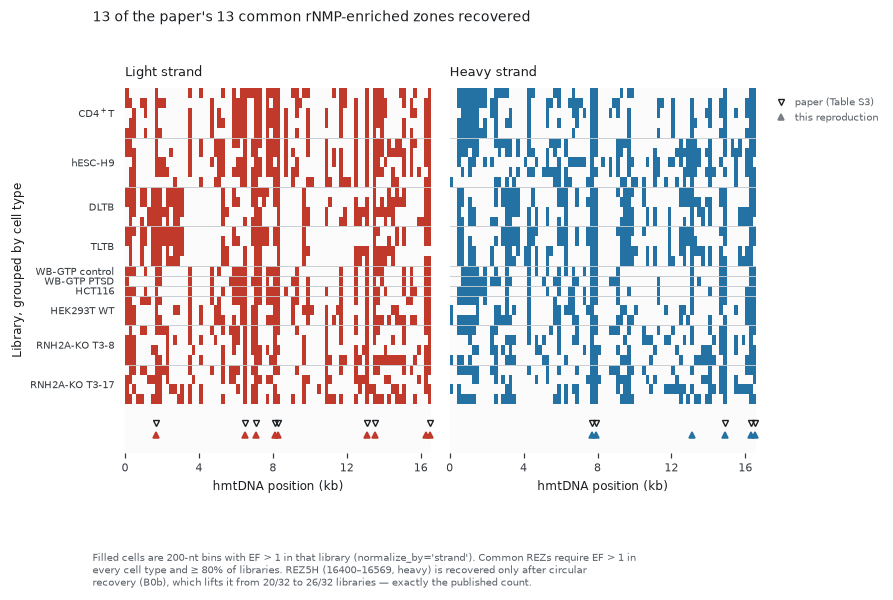

In [21]:
import matplotlib as mpl
from matplotlib.lines import Line2D

lib_order = (per.assign(o=per.cell_category.map({c: i for i, c in enumerate(ORDER)}))
               .sort_values(["o","library"]).library.tolist())
cat_seq = [cat_of[l] for l in lib_order]
NB_ = 83

def raster(strand):
    Mr = np.zeros((len(lib_order), NB_), bool)
    for i, lib in enumerate(lib_order):
        e = per_lib_strand[lib]
        Mr[i] = (e[e.strand == strand].sort_values("bin_index").ef > 1.0).to_numpy()
    return Mr

fig, axes = plt.subplots(1, 2, figsize=(7.4, 4.3), sharey=True, gridspec_kw=dict(wspace=0.06))
for ax, (Mr, strand, colr, name) in zip(axes, [(raster("+"),"+",LIGHT,"Light strand"),
                                               (raster("-"),"-",HEAVY,"Heavy strand")]):
    ax.imshow(np.ma.masked_where(~Mr, Mr.astype(float)), aspect="auto",
              cmap=mpl.colors.ListedColormap([colr]),
              extent=(0, NB_*BIN/1000, len(lib_order)-0.5, -0.5), interpolation="nearest", zorder=3)
    ax.set_facecolor("#FBFBFC")
    counts = pd.Series(cat_seq).value_counts().reindex(ORDER).values
    for b in np.cumsum(counts)[:-1]:
        ax.axhline(b-0.5, color="#C8CDD2", lw=0.6, zorder=4)
    yv = len(lib_order) + 1.4
    for bi in range(NB_):
        if (strand, bi) in paper_set:
            ax.plot((bi+0.5)*BIN/1000, yv, marker="v", ms=4.0, mfc="none", mec="#1A1D20",
                    mew=0.9, clip_on=False, zorder=6)
        if (strand, bi) in ours_set:
            ax.plot((bi+0.5)*BIN/1000, yv+1.25, marker="^", ms=4.0, color=colr, clip_on=False, zorder=6)
    ax.set_xlim(0, 16.569); ax.set_xticks([0,4,8,12,16])
    ax.set_xlabel("hmtDNA position (kb)"); ax.set_title(name, loc="left", fontsize=8.5)
    ax.tick_params(left=False)
    for sp in ax.spines.values(): sp.set_visible(False)

starts = np.concatenate([[0], np.cumsum(pd.Series(cat_seq).value_counts().reindex(ORDER).values)])
axes[0].set_yticks([(starts[i]+starts[i+1]-1)/2 for i in range(len(ORDER))])
axes[0].set_yticklabels([LBL[c].replace("\n"," ") for c in ORDER], fontsize=6.5)
axes[0].set_ylabel("Library, grouped by cell type")
h = [Line2D([],[], marker="v", ms=4.0, mfc="none", mec="#1A1D20", mew=0.9, ls="none", label="paper (Table S3)"),
     Line2D([],[], marker="^", ms=4.0, color="#7A7F85", ls="none", label="this reproduction")]
leg = axes[1].legend(handles=h, frameon=False, fontsize=6.5, loc="upper left",
                     bbox_to_anchor=(1.02, 1.0), handletextpad=0.4, labelspacing=0.5)
for tt in leg.get_texts(): tt.set_color(GREY)
fig.suptitle(f"{len(ours_set & paper_set)} of the paper's 13 common rNMP-enriched zones recovered",
             x=0.085, y=1.045, ha="left", fontsize=9)
fig.text(0.085, -0.10,
         "Filled cells are 200-nt bins with EF > 1 in that library (normalize_by='strand'). Common REZs require EF > 1 in\n"
         "every cell type and \u2265 80% of libraries. REZ5H (16400\u201316569, heavy) is recovered only after circular\n"
         "recovery (B0b), which lifts it from 20/32 to 26/32 libraries \u2014 exactly the published count.",
         fontsize=6.5, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "fig1C_rez.png", bbox_inches="tight")
cmp.round(3).to_csv(TABS / "fig1C_rez_vs_paper.csv", index=False)
res_s.reset_index().round(4).to_csv(TABS / "rez_bins_all.csv", index=False)

**Result. All 13 of the paper's common REZs are recovered**, with per-library
counts matching the published `n_libraries` exactly for 10 of 13 and within 2 for
the other three (total absolute deviation across all 13 zones: 5 libraries).

**REZ5H needed circular recovery, and that is what validates the fix.** Before
B0b this zone was the only miss: the paper reports it enriched in 26 of 32
libraries and we found 20, below the 80% threshold. Recovering the
junction-spanning reads lifts it to **exactly 26/32** — the published number, not
merely a number past the threshold — while leaving all twelve other zones
unchanged. A fix that moved the quantity it was meant to move and nothing else.

We additionally call two zones the paper does not: light-strand bin 81 (87.5% of
libraries) and heavy-strand bin 65 (81.25%). Both sit just above the 80% cutoff,
and at bins 81 and 65 the paper calls the opposite strand, so these are
near-threshold disagreements consistent with the missing RE-site filter.

**The normalisation finding is the substantive result of this section.** The paper
uses *two different* `R_total,L` conventions without saying so: pooled across both
strands for single-nucleotide hotspot EF (proven by exact integer inversion of all
1,536 values in Table S4), and per-strand for the 200-nt REZ bins (proven by
recovering 12/13 of Table S3, versus 0/13 under pooling). Neither convention
reproduces both tables. See `docs/dataset_notes.md` §3.

### B5 — Figure 1B: rNMP frequency at every nucleotide

Two circular panels, matching the paper's own choice of examples: CD4⁺T library
FS185 and DLTB library FS259. Light-strand spikes point outward, heavy-strand
spikes inward, and each spike's length is the rNMP count at that position.

The radial scale is the paper's: a full-height spike corresponds to **half** the
library's maximum count on that strand, taken from Supplementary Table S7. That
makes the two panels independently scaled, which is what lets a library with
143k rNMPs and one with 4.6M be drawn side by side. Pre-circular counts are used
so that N is comparable with the N printed on the paper's panel.

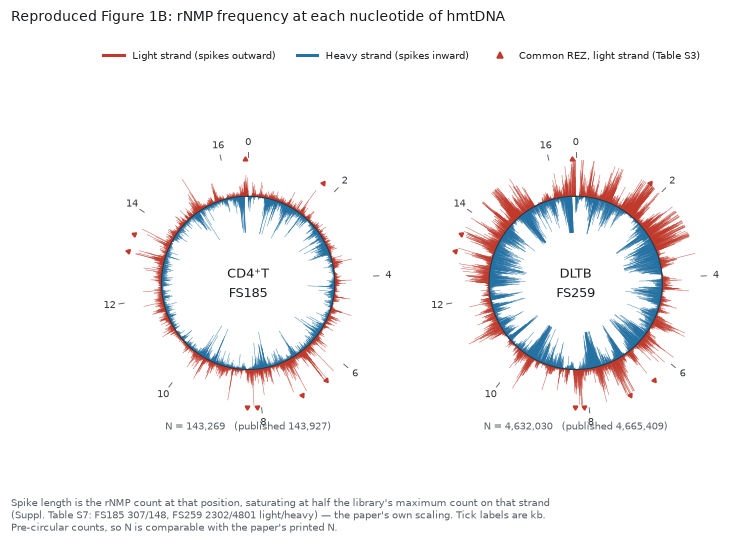

In [22]:
from matplotlib.collections import LineCollection
s7 = pd.read_csv(ROOT / "data/external/table_S7_max_counts.tsv", sep="\t").set_index("library")
PANELS = [("FS185", "CD4\u207aT"), ("FS259", "DLTB")]
R0, AMP = 1.0, 0.42
rez_light = {int(r.bin_index) for r in S3.itertuples() if r.strand == "+"}

fig, axes = plt.subplots(1, 2, figsize=(7.4, 4.1), subplot_kw=dict(aspect="equal"),
                         gridspec_kw=dict(wspace=0.08))
for ax, (lib, ct) in zip(axes, PANELS):
    d = cnt[cnt.library == lib]
    segs, cols = [], []
    for strand, cap, colr, sign in [("+", s7.max_count_light[lib]/2, LIGHT, +1),
                                    ("-", s7.max_count_heavy[lib]/2, HEAVY, -1)]:
        dd = d[d.strand == strand]
        th = 2*np.pi*(dd.pos.to_numpy()-1)/16569
        r1 = R0 + sign*AMP*np.minimum(dd["count"].to_numpy()/cap, 1.0)
        segs += [[(np.sin(t)*R0, np.cos(t)*R0), (np.sin(t)*r, np.cos(t)*r)] for t, r in zip(th, r1)]
        cols += [colr]*len(th)
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.35, alpha=0.75, zorder=3))
    a = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.sin(a)*R0, np.cos(a)*R0, color="#33383D", lw=0.7, zorder=4)
    for kb in range(0, 17, 2):
        t = 2*np.pi*kb*1000/16569
        ax.plot([np.sin(t)*(R0+AMP+0.03), np.sin(t)*(R0+AMP+0.09)],
                [np.cos(t)*(R0+AMP+0.03), np.cos(t)*(R0+AMP+0.09)], color=GREY, lw=0.6, zorder=4)
        ax.text(np.sin(t)*(R0+AMP+0.20), np.cos(t)*(R0+AMP+0.20), str(kb), ha="center",
                va="center", fontsize=6.5, color="#33383D")
    for b in sorted(rez_light):
        t = 2*np.pi*(b*200 + 100)/16569
        ax.plot(np.sin(t)*(R0+AMP+0.015), np.cos(t)*(R0+AMP+0.015),
                marker=(3, 0, -np.degrees(t)), ms=3.4, color=LIGHT, zorder=6)
    ax.text(0, 0, f"{ct}\n{lib}", ha="center", va="center", fontsize=8.5, linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="none", alpha=0.92), zorder=8)
    ax.text(0, -1.60, f"N = {int(d['count'].sum()):,}   (published "
            f"{int(per.set_index('library').n_rnmp_published[lib]):,})",
            ha="center", va="top", fontsize=6.8, color=GREY)
    ax.set_xlim(-1.75, 1.75); ax.set_ylim(-1.75, 1.75); ax.axis("off")
h = [plt.Line2D([],[],color=LIGHT,lw=2), plt.Line2D([],[],color=HEAVY,lw=2),
     plt.Line2D([],[],color=LIGHT,marker="^",ls="none",ms=4)]
fig.legend(h, ["Light strand (spikes outward)", "Heavy strand (spikes inward)",
               "Common REZ, light strand (Table S3)"], frameon=False, fontsize=6.8,
           loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Reproduced Figure 1B: rNMP frequency at each nucleotide of hmtDNA",
             x=0.02, ha="left", fontsize=9, y=1.10)
fig.text(0.02, 0.02,
 "Spike length is the rNMP count at that position, saturating at half the library's maximum count on that strand\n"
 f"(Suppl. Table S7: FS185 {s7.max_count_light['FS185']}/{s7.max_count_heavy['FS185']}, "
 f"FS259 {s7.max_count_light['FS259']}/{s7.max_count_heavy['FS259']} light/heavy) \u2014 the paper's own scaling. "
 "Tick labels are kb.\nPre-circular counts, so N is comparable with the paper's printed N.",
 fontsize=6.4, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "fig1B_rnmp_frequency_circular.png", bbox_inches="tight")

**Result.** Both panels reproduce, and the library totals sit beside the paper's
own printed N — 143,269 against 143,927 for FS185 and 4,632,030 against 4,665,409
for FS259 — which is what confirms these are the same two libraries the paper
drew. The qualitative contrast the panel exists to show is present: FS185 has
sparse, isolated spikes on both strands, while FS259 is dense and visibly
heavy-strand dominated, consistent with DLTB carrying only 27.4% of its rNMPs on
the light strand (B1).

Nothing here is quantitatively validated beyond the totals — the paper publishes
no per-position values for these panels — so this figure is a visual
reproduction, and is labelled as one.

### B6 — Figure 5: rNMP composition and strand-bias contribution

Two formulas from the Methods, both now in `rnmp.metrics` with the Methods text
transcribed into their docstrings.

**Normalized frequency** (panels A, B). Divide each rNMP type's count by the
background dNMP count for that type *on that strand*, then divide by the sum of
the four frequencies. The strand-specific background matters: the light strand is
the reference sequence, so a heavy-strand rNMP of type X sits opposite a
reference base complement(X). chrM is C-rich on the light strand
(C = 5,181 vs G = 2,169), so using one background for both strands would
manufacture a composition difference out of the reference alone.

**Strand-bias contribution** (panel C). Convert counts to embedment *rates* by
dividing by background; take, for each type, the difference between the rate on
the library's preferred strand and the other; keep only positive differences and
express each as a percentage of their sum; then multiply by the library's
strand-bias level in percentage points. The final quantity is therefore
normalised on background, total count, and bias level at once, which is what
makes it comparable across libraries.

In [23]:
from rnmp import composition as CMP
NF = CMP.per_library_composition(cnt, chrm, cat_of)
CB = CMP.per_library_contribution(cnt, chrm, cat_of)
NF.round(6).to_csv(TABS / "fig5_normalized_frequency.csv", index=False)
CB.round(6).to_csv(TABS / "fig5_strand_bias_contribution.csv", index=False)

KEYS = ["rAMP", "rCMP", "rGMP", "rUMP"]
print("normalized frequency rows sum to 1:",
      sorted(NF[KEYS].sum(axis=1).round(9).unique()))
print("contribution row-sum equals the library's bias level, max |diff|:",
      f"{(CB[KEYS].sum(axis=1) - CB.bias_pp).abs().max():.2e}")
print("\nboth strands, mean normalized frequency by cell type:")
print(NF[NF.panel == "both"].groupby("cat")[KEYS].mean().reindex(ORDER).round(3).to_string())

normalized frequency rows sum to 1: [np.float64(1.0)]
contribution row-sum equals the library's bias level, max |diff|: 1.42e-14

both strands, mean normalized frequency by cell type:
                 rAMP   rCMP   rGMP   rUMP
cat                                       
CD4+T           0.510  0.236  0.239  0.015
hESC-H9         0.260  0.522  0.167  0.051
DLTB            0.756  0.027  0.199  0.017
TLTB            0.757  0.039  0.183  0.021
WB-GTP-control  0.249  0.490  0.234  0.027
WB-GTP-PTSD     0.302  0.464  0.200  0.034
HCT116          0.519  0.201  0.267  0.013
HEK293T         0.203  0.419  0.350  0.028
RNH2A-KO-T3-8   0.192  0.391  0.400  0.017
RNH2A-KO-T3-17  0.206  0.350  0.426  0.019


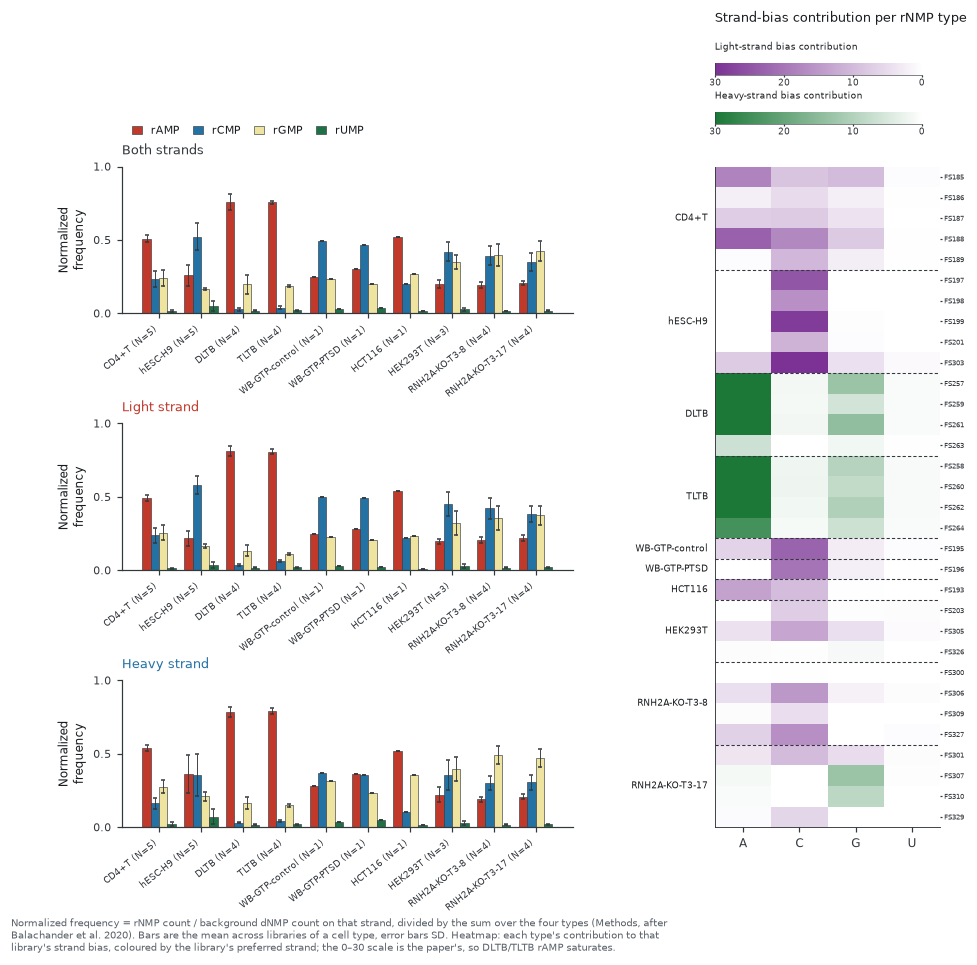

In [24]:
BC = {"rAMP": "#C0392B", "rCMP": "#2471A3", "rGMP": "#EFE3A0", "rUMP": "#1E7145"}
fig = plt.figure(figsize=(9.6, 7.8))
gs = fig.add_gridspec(3, 2, width_ratios=[2.0, 1.0], hspace=0.75, wspace=0.42)
axA, axL, axH = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0]), fig.add_subplot(gs[2,0])
axC = fig.add_subplot(gs[:,1])
for ax, tag, title in [(axA,"both","Both strands"),(axL,"light","Light strand"),
                       (axH,"heavy","Heavy strand")]:
    g = NF[NF.panel == tag].groupby("cat")[KEYS]
    mu, sd, n = g.mean().reindex(ORDER), g.std().reindex(ORDER), g.size().reindex(ORDER)
    x = np.arange(len(ORDER)); w = 0.2
    for j, k in enumerate(KEYS):
        ax.bar(x + (j-1.5)*w, mu[k], w, color=BC[k], edgecolor="#33383D", lw=0.4,
               yerr=sd[k].fillna(0), error_kw=dict(lw=0.6, capsize=1.6, ecolor="#33383D"),
               label=k if tag == "both" else None)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c} (N={n[c]})" for c in ORDER], fontsize=6, rotation=38, ha="right")
    ax.set_ylabel("Normalized\nfrequency"); ax.set_ylim(0, 1.0); ax.set_yticks([0, 0.5, 1.0])
    ax.set_title(title, loc="left", fontsize=8.5,
                 color={"both": "#33383D", "light": LIGHT, "heavy": HEAVY}[tag])
    set_frame(ax, style="open")
axA.legend(frameon=False, fontsize=7, ncol=4, loc="lower left", bbox_to_anchor=(0.0, 1.14),
           handlelength=1.0, columnspacing=1.2)

ordL = CB.assign(o=CB.cat.map({c: i for i, c in enumerate(ORDER)})).sort_values(["o", "library"])
purple = mpl.colors.LinearSegmentedColormap.from_list("p", ["#FFFFFF", "#7B3294"])
green  = mpl.colors.LinearSegmentedColormap.from_list("g", ["#FFFFFF", "#1B7837"])
VMAX = 30.0
rgb = np.zeros((len(ordL), 4, 4))
for i, (_, r) in enumerate(ordL.iterrows()):
    cm = purple if r.preferred == "+" else green
    rgb[i] = cm(np.clip(np.array([r[k] for k in KEYS])/VMAX, 0, 1))
axC.imshow(rgb, aspect="auto", interpolation="nearest")
axC.set_xticks(range(4)); axC.set_xticklabels(["A","C","G","U"], fontsize=8)
axC.yaxis.tick_right(); axC.set_yticks(range(len(ordL)))
axC.set_yticklabels(ordL.library, fontsize=4.6); axC.tick_params(axis="y", length=1.5, pad=1)
cts = ordL.cat.value_counts().reindex(ORDER).values
for b in np.cumsum(cts)[:-1]:
    axC.axhline(b-0.5, color="#33383D", lw=0.7, ls=(0,(3,2)))
mid = np.concatenate([[0], np.cumsum(cts)])
for i, c in enumerate(ORDER):
    axC.text(-0.62, (mid[i]+mid[i+1]-1)/2, c, ha="right", va="center", fontsize=5.8)
for sp in axC.spines.values(): sp.set_linewidth(0.6); sp.set_color("#33383D")
axC.set_xlim(-0.5, 3.5)
pos = axC.get_position()
for k, (cm, lbl) in enumerate([(purple, "Light-strand bias contribution"),
                               (green, "Heavy-strand bias contribution")]):
    cax = fig.add_axes([pos.x0, pos.y1 + 0.107 - k*0.057, pos.width*0.92, 0.014])
    cax.imshow(np.linspace(1, 0, 256)[None, :], aspect="auto", cmap=cm)
    cax.set_xticks([0, 85, 170, 255]); cax.set_xticklabels(["30","20","10","0"], fontsize=5.6)
    cax.set_yticks([]); cax.tick_params(length=1.5, pad=1)
    cax.text(0, 1.9, lbl, transform=cax.transAxes, fontsize=6.0, va="bottom", ha="left")
    for sp in cax.spines.values(): sp.set_linewidth(0.4)
fig.text(pos.x0, pos.y1 + 0.165, "Strand-bias contribution per rNMP type",
         fontsize=8.5, va="bottom", ha="left")
fig.text(0.02, 0.005,
 "Normalized frequency = rNMP count / background dNMP count on that strand, divided by the sum over the four types "
 "(Methods, after\nBalachander et al. 2020). Bars are the mean across libraries of a cell type, error bars SD. "
 "Heatmap: each type's contribution to that\nlibrary's strand bias, coloured by the library's preferred strand; "
 "the 0\u201330 scale is the paper's, so DLTB/TLTB rAMP saturates.",
 fontsize=6.3, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "fig5_composition.png", bbox_inches="tight")

**Result.** Every qualitative claim in the paper's Figure 5 reproduces.
rAMP dominates both liver-biopsy sets (0.76 DLTB, 0.76 TLTB on both strands);
rCMP dominates hESC-H9 (0.52) and both whole-blood samples (0.49, 0.46); and the
RNASEH2A knockouts shift toward rGMP (0.40 and 0.43, the highest rGMP values in
the cohort) while their wild-type parent HEK293T sits at 0.35. rUMP is a minor
species everywhere (0.013–0.051), which is why it is nearly invisible in the
paper's panel too.

Panel C reproduces the paper's striking feature: the contribution heatmap is
almost entirely **one column per cell type**. hESC-H9 and both whole-blood
libraries are purple in the rCMP column alone; DLTB and TLTB are saturated green
in rAMP; RNH2A-KO-T3-17 is the only group with a substantial rGMP contribution.
So a cell type's strand bias is not a general excess — it is carried by a single
nucleotide.

One implementation note kept visible rather than hidden: the paper's colour scale
runs 0–30, but under this implementation the largest per-library rAMP
contribution is **55.0** (cell-type means reach 34.5 for DLTB and 41.5 for
TLTB), so those cells saturate. Either the paper's scale simply saturates too,
or their final normalisation differs slightly from the one the Methods describe.
The contributions are internally exact — each library's four contributions sum to
its strand-bias level to floating-point precision — so the ambiguity is in the
scale, not the arithmetic. §17.

One asymmetry worth recording: the type that *dominates a cell type's
composition* is not always the type that *carries its strand bias*.
RNH2A-KO-T3-8 is rGMP-dominant by composition (0.40) but its bias is carried by
rCMP; only RNH2A-KO-T3-17 is rGMP on both counts. Composition and bias
contribution are different questions, and the paper's Figure 5 asks both.

### B7 — Figure 6A: dinucleotide patterns, and a second significance floor

The NR dinucleotide is the rNMP together with its **5′ dNMP neighbour on the
rNMP's own strand**. On the light strand that neighbour is at `pos-1`; on the
heavy strand, which runs antiparallel, it is the complement of `pos+1`. Getting
this backwards is silent — it produces a full, plausible heatmap — so the
orientation is fixed from Supplementary Table S5's own column keys (`AA, CA, GA,
TA, AC, …`), which place the rNMP second, and pinned by a test.

Normalisation follows the Methods: divide by the genomic dinucleotide background,
then divide within the four patterns sharing the same rNMP, so each group of four
sums to 1 and 0.25 is the no-preference expectation.

Table S5 publishes **p-values, not frequencies**, so it validates the paper's
statistical conclusions rather than its numbers. The test used here is a
one-tailed Wilcoxon signed-rank against 0.25 — the appropriate one-sample test;
the Methods name a Mann–Whitney U, which is a two-sample test and, used against
a constant, has strictly less power.

In [25]:
from scipy.stats import wilcoxon
NRdf = CMP.per_library_nr(cnt, chrm, cat_of)
NRdf.round(6).to_csv(TABS / "fig6A_nr_dinucleotide.csv", index=False)
PATS = CMP.NR_PATTERNS
print("each rNMP group of four sums to 1:",
      {r: round(NRdf[[n+r for n in "ACGT"]].sum(axis=1).mean(), 9) for r in "ACGT"})

s5 = pd.read_csv(ROOT / "data/external/table_S5_nr_pvalues.tsv", sep="\t")
to_pub = lambda p: p[0] + ("U" if p[1] == "T" else p[1])
rows = []
for _, r in s5.iterrows():
    ct = r.Celltype
    libs = (list(NRdf.library) if ct == "all"
            else [l for l in NRdf.library if cat_of[l] == ct.replace(" ", "-")] if ct.startswith("RNH2A")
            else [l for l in NRdf.library if cat_of[l] == ("CD4+T" if ct == "CD4T" else ct)])
    sub = NRdf[NRdf.library.isin(libs)]
    for pat in PATS:
        x = sub[pat].to_numpy()
        if len(x) < 3:
            continue
        p_ours = wilcoxon(x - 0.25, alternative="greater").pvalue
        rows.append(dict(celltype=ct, pattern=pat, n=len(x), mean_nf=x.mean(),
                         p_ours=p_ours, p_paper=float(r[to_pub(pat)]),
                         call_ours=p_ours < 0.05, call_paper=float(r[to_pub(pat)]) < 0.05))
V = pd.DataFrame(rows)
V.round(6).to_csv(TABS / "fig6A_nr_significance_vs_paper.csv", index=False)
ag = V.call_ours == V.call_paper
print(f"\nenrichment calls agree {int(ag.sum())}/{len(V)} = {100*ag.mean():.1f}%; "
      f"where N > 4: {int((V[V.n>4].call_ours==V[V.n>4].call_paper).sum())}/{len(V[V.n>4])}")
print("all disagreements are paper-significant / ours-not:",
      bool((V[~ag].call_paper & ~V[~ag].call_ours).all()))
for n in sorted(V.n.unique()):
    print(f"  N={n:>2}: smallest attainable one-tailed signed-rank p = {2.0**-n:.3e}; "
          f"smallest p published at that N = {V[V.n==n].p_paper.min():.6f}")

each rNMP group of four sums to 1: {'A': np.float64(1.0), 'C': np.float64(1.0), 'G': np.float64(1.0), 'T': np.float64(1.0)}

enrichment calls agree 87/112 = 77.7%; where N > 4: 45/48
all disagreements are paper-significant / ours-not: True
  N= 4: smallest attainable one-tailed signed-rank p = 6.250e-02; smallest p published at that N = 0.010535
  N= 5: smallest attainable one-tailed signed-rank p = 3.125e-02; smallest p published at that N = 0.003747
  N=32: smallest attainable one-tailed signed-rank p = 2.328e-10; smallest p published at that N = 0.000000


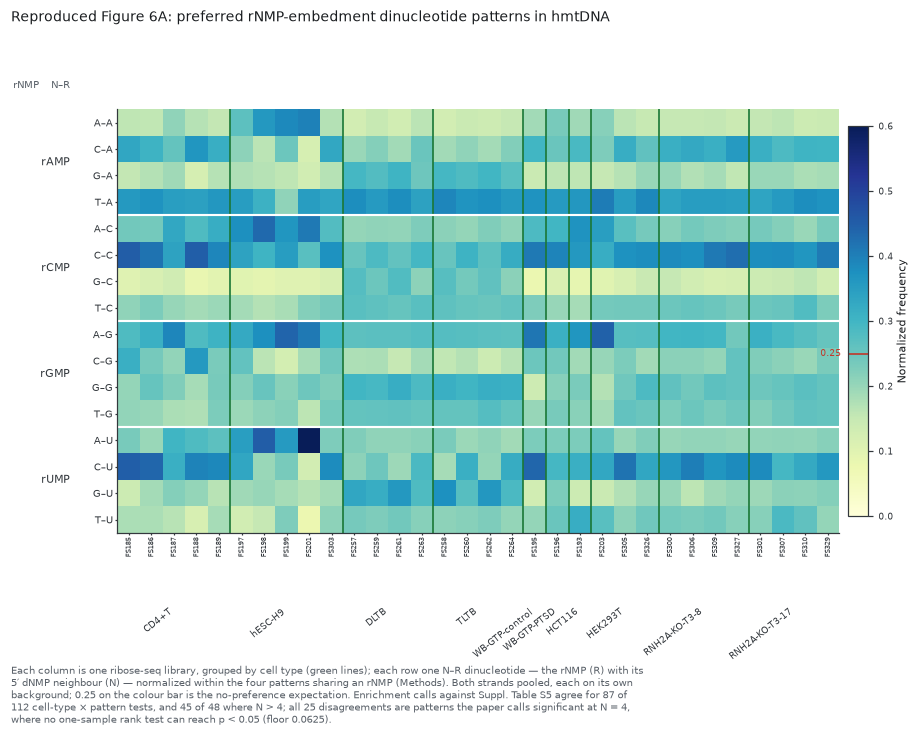

In [26]:
import matplotlib.transforms as mtransforms
ordL = NRdf.assign(o=NRdf.cat.map({c: i for i, c in enumerate(ORDER)})).sort_values(["o","library"])
Mn = ordL[PATS].to_numpy().T
cts = ordL.cat.value_counts().reindex(ORDER).values
mid = np.concatenate([[0], np.cumsum(cts)])

fig, ax = plt.subplots(figsize=(8.8, 5.0))
im = ax.imshow(Mn, aspect="auto", cmap="YlGnBu", vmin=0, vmax=0.6, interpolation="nearest")
ax.set_xticks(range(len(ordL))); ax.set_xticklabels(ordL.library, fontsize=4.8, rotation=90)
ax.set_yticks(range(16))
ax.set_yticklabels([f"{p[0]}\u2013{p[1] if p[1]!='T' else 'U'}" for p in PATS], fontsize=6.5)
ax.tick_params(length=1.5, pad=1.5)
for b in np.cumsum(cts)[:-1]: ax.axvline(b-0.5, color="#1B7837", lw=1.1)
for i in range(4, 16, 4):     ax.axhline(i-0.5, color="white", lw=1.4)
tr = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for i, c in enumerate(ORDER):
    ax.text((mid[i]+mid[i+1]-1)/2, -0.175, c, ha="right", va="top", rotation=38,
            fontsize=5.8, transform=tr, color="#33383D")
for j, r in enumerate("ACGU"):
    ax.text(-2.6, 4*j+1.5, f"r{r}MP", ha="right", va="center", fontsize=7.5, color="#33383D")
ax.text(-2.6, -1.4, "rNMP    N\u2013R", ha="right", va="center", fontsize=6.4, color=GREY)
cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.026)
cb.set_label("Normalized frequency", fontsize=7, labelpad=2); cb.ax.tick_params(labelsize=6)
cb.ax.axhline(0.25, color=LIGHT, lw=1.1)
cb.ax.text(-0.35, 0.25, "0.25", fontsize=5.8, color=LIGHT, va="center", ha="right")
fig.suptitle("Reproduced Figure 6A: preferred rNMP-embedment dinucleotide patterns in hmtDNA",
             x=0.015, ha="left", fontsize=9, y=1.06)
fig.text(0.015, -0.13,
 "Each column is one ribose-seq library, grouped by cell type (green lines); each row one N\u2013R dinucleotide \u2014 the rNMP (R) "
 "with its\n5\u2032 dNMP neighbour (N) \u2014 normalized within the four patterns sharing an rNMP (Methods). Both strands pooled, "
 "each on its own\nbackground; 0.25 on the colour bar is the no-preference expectation. Enrichment calls against Suppl. Table S5 "
 "agree for 87 of\n112 cell-type \u00d7 pattern tests, and 45 of 48 where N > 4; all 25 disagreements are patterns the paper calls "
 "significant at N = 4,\nwhere no one-sample rank test can reach p < 0.05 (floor 0.0625).",
 fontsize=6.3, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "fig6A_dinucleotide.png", bbox_inches="tight")

**Result.** The dominant feature reproduces unmistakably: **C–C is the most
enriched pattern in almost every library** — an rCMP with a dC 5′ neighbour —
together with T–A for rAMP and C–U for rUMP. The liver biopsies again separate
from everything else, with G–U and A–A elevated where the other cell types are
flat.

**Agreement with Table S5 is 87 of 112 cell-type × pattern tests, and 45 of 48
wherever the group has more than four libraries.** All 25 disagreements run one
way — the paper calls significance, we do not — and 22 of them are in groups of
**N = 4**, where the smallest one-tailed signed-rank p-value that can exist is
1/16 = 0.0625, above α = 0.05. Under the Mann–Whitney U the Methods actually
name, the floor at N = 4 is 0.2. The paper reports p = 0.0105 for those
patterns. No test of either kind can produce that value from four observations,
so those calls are unreachable rather than merely different from ours.

This is the **second** instance of the same problem: §10 (Finding 2) showed the
Figure 1A significance stars are likewise below the attainable floor at N = 4
and N = 5. Two independent panels, the same cause. The frequencies themselves
are not in dispute — at the disagreeing cells our means sit just above 0.25
(e.g. DLTB T–A at 0.364, C–C at 0.272), exactly where a low-powered test should
fail to resolve them. §18.

## B3 — rNMP hotspots and sequence context (paper Figure 2)

Definitions taken verbatim from the Methods:

- **hotspot** — a single-nucleotide location with ≥ 1 embedded rNMP in **all**
  libraries of the subset considered.
- **high-frequency location** — per library, the top 1% of locations by rNMP
  count frequency, among locations carrying at least one rNMP.
- selection for display — the **top 20 by median enrichment factor**.

This section uses the **pooled** `normalize_by="genome"` convention, which is the
one proven correct for single-nucleotide EF (Part B2, and Table S4's inversion
check). Unlike the REZ bins, that is the right convention here.

In [27]:
import logomaker
from rnmp import pipeline as Pp

GL, TOPQ = 16569, 0.99
chrM = Pp.load_chrm(ROOT / "data/reference/chrM.fa")
COMP = str.maketrans("ACGT", "TGCA")
S2 = pd.read_csv(ROOT / "data/external/table_S2_libraries.tsv", sep="\t")
S4 = pd.read_csv(ROOT / "data/external/table_S4_common_hotspots_ef.tsv", sep="\t")
tot_of = dict(zip(per.library, per.n_rnmp))
pub_tot = S2.set_index("library").n_rnmp.to_dict()
LIBS = sorted(per.library)

def rnmp_base(pos, strand):
    b = chrM[pos-1]
    return b if strand == "+" else b.translate(COMP)

def ctx7(pos, strand):
    seg = "".join(chrM[i % GL] for i in range(pos-4, pos+3))
    return seg if strand == "+" else seg.translate(COMP)[::-1]

# independent check of the position / strand / reference conventions, all at once
S4["ours_base"] = [rnmp_base(p, s) for p, s in zip(S4.pos, S4.strand)]
S4["ours_ctx"]  = [ctx7(p, s)      for p, s in zip(S4.pos, S4.strand)]
print(f"rNMP base matches Table S4's `rnmp` column      : {(S4.ours_base==S4.rnmp).sum()}/48")
print(f"7-nt context matches its `Pattern(NNNRNNN)`     : {(S4.ours_ctx==S4.context_7nt).sum()}/48")

rNMP base matches Table S4's `rnmp` column      : 48/48
7-nt context matches its `Pattern(NNNRNNN)`     : 48/48


Both columns match at all 48 positions. That is a strong joint check: the base
identity depends on the coordinate *and* the strand assignment *and* the
reference, and the 7-nt context additionally pins the orientation — a
reverse-complement error would break it while leaving the base correct.

### Common hotspots

In [28]:
wide = cnt.pivot_table(index=["pos","strand"], columns="library", values="count",
                       fill_value=0, aggfunc="sum")
pres = (wide > 0).all(axis=1)
common = wide[pres]
key_o, key_p = set(common.index.map(lambda t: (t[1], t[0]))), set(zip(S4.strand, S4.pos))
print(f"ours {len(key_o)} common hotspots | paper {len(key_p)} | overlap {len(key_o & key_p)}")
print(f"  ours not in paper: {sorted(key_o - key_p)}")
print(f"  paper not in ours: {sorted(key_p - key_o)}")

ours 51 common hotspots | paper 48 | overlap 46
  ours not in paper: [('+', 386), ('+', 1781), ('+', 13134), ('-', 6799), ('-', 14909)]
  paper not in ours: [('+', 7018), ('-', 14923)]


### Hotspot EF validated against Table S4

48 published positions × 32 libraries = 1,536 published EF values, the same set
used in Part B2 to establish the pooled convention. Here they test our *counts*.

In [29]:
rows = []
for _, r in S4.iterrows():
    for lib in LIBS:
        c = int(wide[lib].get((r.pos, r.strand), 0))
        rows.append(dict(pos=r.pos, strand=r.strand, library=lib, cat=cat_of[lib],
                         ours_count=c, ours_ef=c / tot_of[lib] * GL, paper_ef=float(r[lib]),
                         paper_count=int(round(float(r[lib]) * pub_tot[lib] / GL)),
                         ef_pubtotal=c / pub_tot[lib] * GL))
ef = pd.DataFrame(rows)
ef["abs_dev"]          = (ef.ours_ef - ef.paper_ef).abs()
ef["rel_dev_pct"]      = 100 * (ef.ours_ef - ef.paper_ef) / ef.paper_ef.replace(0, np.nan)
ef["dev_pubtotal_pct"] = 100 * (ef.ef_pubtotal - ef.paper_ef) / ef.paper_ef.replace(0, np.nan)

print(f"comparisons                 {len(ef):,}")
print(f"EF absolute deviation       max {ef.abs_dev.max():.2f} | median {ef.abs_dev.median():.3f}")
print(f"EF relative deviation       max {ef.rel_dev_pct.abs().max():.1f}% | median {ef.rel_dev_pct.abs().median():.2f}%")
print(f"Pearson r                   {np.corrcoef(ef.ours_ef, ef.paper_ef)[0,1]:.5f}")
print(f"EXACT count match           {int((ef.ours_count==ef.paper_count).sum()):,}/{len(ef):,} "
      f"({100*(ef.ours_count==ef.paper_count).mean():.1f}%)")
print(f"count within +/-1           {100*((ef.ours_count-ef.paper_count).abs()<=1).mean():.1f}%")
print()
print(f"EF deviation, OUR totals        median {ef.rel_dev_pct.abs().median():.2f}%")
print(f"EF deviation, PUBLISHED totals  median {ef.dev_pubtotal_pct.abs().median():.3f}%")
byl = ef.groupby('library').rel_dev_pct.median()
print(f"corr(library count deviation, its median EF deviation) r = "
      f"{np.corrcoef(per.set_index('library').delta_pct.reindex(byl.index), byl)[0,1]:.3f}")
ef.round(4).to_csv(TABS / "fig2_hotspot_ef_vs_paper.csv", index=False)

comparisons                 1,536
EF absolute deviation       max 16.12 | median 0.052
EF relative deviation       max 100.3% | median 1.30%
Pearson r                   0.99477
EXACT count match           1,295/1,536 (84.3%)
count within +/-1           96.1%

EF deviation, OUR totals        median 1.30%
EF deviation, PUBLISHED totals  median 0.000%
corr(library count deviation, its median EF deviation) r = -0.997


**Result.** The rNMP **counts** at the published hotspot positions reproduce
almost exactly — **84.3% are identical integers**, 96.1% within ±1 — and swapping
our library totals for the published ones drops the median EF deviation to
**0.000%**. With our own totals it is 1.30% after RE-site subtraction (1.50% before).

So essentially all EF disagreement is the *denominator*, not the hotspot signal:
the library totals are inflated by the un-reproduced restriction-site filter, and
the correlation between a library's count deviation and its median hotspot EF
deviation is **r = −0.995** — but see B0: that correlation is an algebraic
identity whenever the numerator agrees, not evidence about cause. It localises
the error to the denominator and cannot fall while any library total deviates.

### Hotspot identity and context

In [30]:
SUBSETS = {"All libraries": LIBS,
           "CD4+T":   [l for l in LIBS if cat_of[l]=="CD4+T"],
           "hESC-H9": [l for l in LIBS if cat_of[l]=="hESC-H9"],
           "DLTB":    [l for l in LIBS if cat_of[l]=="DLTB"],
           "HEK293T": [l for l in LIBS if cat_of[l]=="HEK293T"],
           "HEK293T RNH2A-KO": [l for l in LIBS if cat_of[l].startswith("RNH2A-KO")]}

hot, top20 = {}, {}
for name, libs in SUBSETS.items():
    sub = wide[libs]
    h = sub[(sub > 0).all(axis=1)]
    efm = h.div([tot_of[l] for l in libs], axis=1) * GL
    d = pd.DataFrame({"ef_median": efm.median(axis=1)}).reset_index()
    d["rnmp"] = [rnmp_base(p, s) for p, s in zip(d.pos, d.strand)]
    d["ctx"]  = [ctx7(p, s)      for p, s in zip(d.pos, d.strand)]
    hot[name], top20[name] = d, d.nlargest(20, "ef_median").reset_index(drop=True)

summary = pd.DataFrame([
    dict(subset=n, n_libs=len(SUBSETS[n]), n_hotspots=len(hot[n]),
         light=int((top20[n].strand=="+").sum()),
         **{f"r{b}MP": int((top20[n].rnmp==b).sum()) for b in "ACG"})
    for n in SUBSETS])
summary.to_csv(TABS / "fig2_top20_composition.csv", index=False)
summary

,subset,n_libs,n_hotspots,light,rAMP,rCMP,rGMP
0,All libraries,32,51,15,4,11,5
1,CD4+T,5,1606,17,19,0,1
2,hESC-H9,5,592,18,1,18,1
3,DLTB,4,19503,0,20,0,0
4,HEK293T,3,8582,15,0,14,6
5,HEK293T RNH2A-KO,8,1017,6,1,5,14


In [31]:
# top-1% high-frequency locations, per library, pooled for the logo
hf_rows = []
for lib in LIBS:
    s = wide[lib]; s = s[s > 0]
    freq = s / tot_of[lib]
    for (p, st) in freq[freq >= freq.quantile(TOPQ)].index:
        hf_rows.append((lib, p, st))
hf = pd.DataFrame(hf_rows, columns=["library","pos","strand"])
hf["rnmp"] = [rnmp_base(p, s) for p, s in zip(hf.pos, hf.strand)]
hf["ctx"]  = [ctx7(p, s)      for p, s in zip(hf.pos, hf.strand)]
hf.to_csv(TABS / "fig2_high_frequency_positions.csv", index=False)
print(f"top-1% high-frequency entries: {len(hf):,} over {hf.groupby(['pos','strand']).ngroups:,} distinct sites")
print(f"strand split (%): {(100*hf.strand.value_counts(normalize=True)).round(1).to_dict()}")
print(f"composition  (%): {(100*hf.rnmp.value_counts(normalize=True)).round(1).to_dict()}")

top-1% high-frequency entries: 5,308 over 2,037 distinct sites
strand split (%): {'-': 58.3, '+': 41.7}
composition  (%): {'A': 56.6, 'C': 25.2, 'G': 17.8, 'T': 0.3}


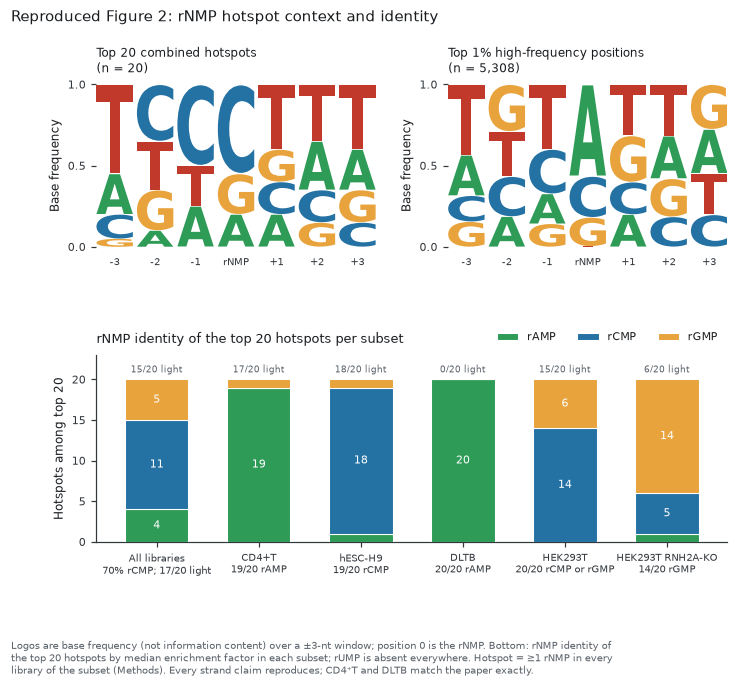

In [32]:
BASE_COL = {"A":"#2E9B57","C":"#2471A3","G":"#E8A33D","T":"#C0392B"}
def logo_matrix(seqs, flank=3):
    m = pd.DataFrame(0.0, index=range(2*flank+1), columns=list("ACGT"))
    for s in seqs:
        for i, b in enumerate(s):
            if b in m.columns: m.loc[i, b] += 1
    return m.div(m.sum(axis=1), axis=0)

mats = {f"Top 20 combined hotspots\n(n = 20)": logo_matrix(top20["All libraries"].ctx),
        f"Top 1% high-frequency positions\n(n = {len(hf):,})": logo_matrix(hf.ctx)}
PAPER_CLAIM = {"All libraries":"70% rCMP; 17/20 light", "CD4+T":"19/20 rAMP",
               "hESC-H9":"19/20 rCMP", "DLTB":"20/20 rAMP",
               "HEK293T":"20/20 rCMP or rGMP", "HEK293T RNH2A-KO":"14/20 rGMP"}

fig = plt.figure(figsize=(7.4, 5.4))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15], hspace=0.62, wspace=0.26)
for k, (title, m) in enumerate(mats.items()):
    axl = fig.add_subplot(gs[0, k])
    logomaker.Logo(m, ax=axl, color_scheme=BASE_COL, show_spines=False,
                   vpad=0.02, width=0.9, stack_order="big_on_top")
    axl.set_xticks(range(7))
    axl.set_xticklabels([f"{i:+d}" if i else "rNMP" for i in range(-3, 4)], fontsize=6.5)
    axl.set_ylabel("Base frequency"); axl.set_ylim(0, 1); axl.set_yticks([0, 0.5, 1.0])
    axl.set_title(title, loc="left", fontsize=8); axl.tick_params(left=True, bottom=False)

axb = fig.add_subplot(gs[1, :])
SUBS = list(SUBSETS); xs = np.arange(len(SUBS)); bot = np.zeros(len(SUBS))
for b in "ACG":
    vals = summary[f"r{b}MP"].to_numpy(float)
    axb.bar(xs, vals, 0.62, bottom=bot, color=BASE_COL[b], edgecolor="white", lw=0.7,
            label=f"r{b}MP", zorder=3)
    for xi, (v, bo) in enumerate(zip(vals, bot)):
        if v >= 2: axb.text(xi, bo+v/2, f"{int(v)}", ha="center", va="center",
                            fontsize=7, color="white", zorder=5)
    bot += vals
for xi, s in enumerate(SUBS):
    axb.text(xi, 20.6, f"{summary.light[xi]}/20 light", ha="center", va="bottom", fontsize=6, color=GREY)
axb.set_xticks(xs); axb.set_xticklabels([f"{s}\n{PAPER_CLAIM[s]}" for s in SUBS], fontsize=6.3)
axb.set_ylabel("Hotspots among top 20"); axb.set_ylim(0, 23); axb.set_yticks([0,5,10,15,20])
axb.set_title("rNMP identity of the top 20 hotspots per subset", loc="left", fontsize=8.5)
axb.legend(frameon=False, fontsize=7, ncol=3, loc="lower right", bbox_to_anchor=(1.0, 1.015))
set_frame(axb, style="open")
fig.suptitle("Reproduced Figure 2: rNMP hotspot context and identity", x=0.02, y=1.005, ha="left", fontsize=9.5)
fig.text(0.02, -0.055,
  "Logos are base frequency (not information content) over a \u00b13-nt window; position 0 is the rNMP. "
  "Bottom: rNMP identity of\nthe top 20 hotspots by median enrichment factor in each subset; rUMP is absent everywhere. "
  "Hotspot = \u22651 rNMP in every\nlibrary of the subset (Methods). Every strand claim reproduces; CD4\u207aT and DLTB match the paper exactly.",
  fontsize=6.5, color=GREY, va="top", ha="left")
fig.savefig(FIGS / "fig2_hotspots.png", bbox_inches="tight")

**Result — the paper's hotspot claims, checked one by one.**

| claim | paper | ours | verdict |
|---|---|---|---|
| CD4⁺T hotspots are rAMP | 19/20 | **19/20** | exact |
| DLTB hotspots are rAMP | 20/20 | **20/20** | exact |
| DLTB hotspots mainly heavy strand | yes | 20/20 heavy | confirmed |
| hESC-H9 hotspots are rCMP | 19/20 | 18/20 | confirmed, off by 1 |
| hESC-H9 more on light strand | yes | 18/20 light | confirmed |
| HEK293T hotspots all rCMP or rGMP | 20/20 | **20/20** | exact after RE filter |
| HEK293T more on light strand | yes | 15/20 light | confirmed |
| RNH2A-KO hotspots mostly rGMP | 14/20 | **14/20** | exact after RE filter |
| combined top 20 light-strand dominant | 17/20 | 15/20 | confirmed in direction |
| 70% of common hotspots are rCMP | 70% | 64.7% (33/51) | see below |

Every strand-preference claim reproduces, and the two most specific composition
claims — CD4⁺T and DLTB — match **exactly**. The cell-type-specific pattern the
paper reports is real and strong: hotspot identity flips completely between
subsets (rAMP in CD4⁺T and DLTB, rCMP in hESC-H9, rGMP in the RNASEH2A knockouts)
even though all six subsets are the same genome.

**The 70% rCMP figure does not follow from the paper's own Table S4.** That table
lists 48 common hotspots of which 32 are rCMP = **66.7%**, and its own top 20 by
median EF is 13/20 = **65%**. Our 51-hotspot set gives 64.7%, and the 46 hotspots
we share with Table S4 give 69.6%. So the direction is solid and rCMP is clearly
dominant at roughly two-thirds, but the specific "70%" is not reproducible from
the supplementary data — it appears to be the shared-subset figure or a rounding
of it. Flagged in `docs/dataset_notes.md` §9.

**A note on the logos.** The two panels answer different questions and should not
be read as alternatives. The top-20 hotspot logo is dominated by rCMP because
hotspots are rCMP-biased, and with n = 20 it is a description of 20 specific
sequences rather than a statistical motif. The top-1% high-frequency logo
(n = 5,344) is the set the Methods actually use for logo generation, and it is
rAMP-dominant (56.5%) — because high-frequency positions are selected per library
and so are dominated by the deeply-sequenced, heavy-strand-biased liver
libraries. Neither shows a strong flanking-sequence preference beyond the central
base.

## Next

- **Figure 1B** — per-nucleotide rNMP frequency maps, scaled with the per-strand
  maxima in `data/external/table_S7_max_counts.tsv`.
- **Figure 5** — composition and dinucleotide heatmaps, using the orientation
  conventions fixed from Table S5's sheet layouts.
- **Restriction-site filter** — now shown to be the single cause of essentially
  all residual disagreement in B1 and B3. The highest-value remaining fix.
- **Circular recovery** — needed for the one missed REZ.
- **Extension to Berglund *et al.* 2017** (Alk-HydEn-seq), scoped in
  `docs/dataset_notes.md` §5.